# PLM и филогенетическое взвешивание последовательностей

Версия ноутбука без блока `Phylo Signal`.

Что делает ноутбук:

1. Загружает и разбирает Pandit/Pfam.
2. Выбирает 300 семейств.
3. Считает несколько вариантов phylogenetic weights.
4. Строит embeddings для двух ESM2-моделей.
5. Считает unsupervised PLM-based weights.
6. Строит PLM-derived local features.
7. Анализирует связь local features с phylogenetic weights.
8. Обучает supervised regression на train families и проверяет на unseen test families.
9. Проверяет feature ablation.
10. Проверяет ranking-постановку и learning-to-rank модели.
11. Сохраняет таблицы и графики.

Важно: split выполняется по семействам, а не по отдельным последовательностям.


## 1. Безопасная установка зависимостей

In [1]:
import importlib.util
import subprocess
import sys

def install_if_missing(import_name, package_name=None):
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print("installing", package_name)
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])

for import_name, package_name in [
    ("ete3", "ete3"),
    ("transformers", "transformers"),
    ("sentencepiece", "sentencepiece"),
]:
    try:
        install_if_missing(import_name, package_name)
    except Exception as e:
        print("install warning:", package_name, repr(e))

try:
    install_if_missing("lightgbm", "lightgbm")
except Exception as e:
    print("LightGBM is unavailable:", repr(e))

try:
    install_if_missing("xgboost", "xgboost")
except Exception as e:
    print("XGBoost is unavailable:", repr(e))

installing ete3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.9 MB/s eta 0:00:00


## 2. Импорты и настройки

In [2]:
import gzip
import gc
import os
import random
import re
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from ete3 import Tree
from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Robustness utilities

In [3]:
def clean_numeric_frame(df, fill_value=0.0):
    df = df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            median = df[col].median()
            if pd.isna(median):
                median = fill_value
            df[col] = df[col].fillna(median)

    return df


def clean_array(x, fill_value=0.0):
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(
        x,
        nan=fill_value,
        posinf=fill_value,
        neginf=fill_value,
    )
    return x


def safe_std(x):
    x = clean_array(x)
    if len(x) == 0:
        return 0.0
    return float(np.std(x))


def safe_normalize_array_weights(raw_weights, normalize_sum):
    raw_weights = clean_array(raw_weights, fill_value=0.0)

    raw_weights[raw_weights < 0] = 0.0
    total = float(raw_weights.sum())

    if len(raw_weights) == 0:
        return raw_weights

    if not np.isfinite(total) or total <= 1e-12:
        return np.ones_like(raw_weights, dtype=float) * (normalize_sum / len(raw_weights))

    return raw_weights * normalize_sum / total


def safe_fill_feature_matrix(df):
    df = clean_numeric_frame(df)
    return df.replace([np.inf, -np.inf], 0.0).fillna(0.0)


def safe_corr(x, y):
    x = clean_array(x)
    y = clean_array(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan

    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan, np.nan

    return spearmanr(x, y)[0], pearsonr(x, y)[0]

## 3. Конфигурация эксперимента

In [4]:
DATA_URL = "https://www.ebi.ac.uk/goldman-srv/pandit/Pandit/data/Pandit17.0.gz"
DATA_PATH = Path("/content/Pandit17.0.gz")

WORK_DIR = Path("/content/plm_phylo_project")
EMB_DIR = WORK_DIR / "embeddings"
WEIGHT_DIR = WORK_DIR / "phylogenetic_weights"
FEATURE_DIR = WORK_DIR / "features"
RESULT_DIR = WORK_DIR / "results"
FIG_DIR = WORK_DIR / "figures"

for path in [WORK_DIR, EMB_DIR, WEIGHT_DIR, FEATURE_DIR, RESULT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MIN_ANO = 100
N_FAMILIES = 300
TARGET_MEAN_ANO = 500

MODEL_CONFIGS = {
    "esm2_8m": "facebook/esm2_t6_8M_UR50D",
    "esm2_35m": "facebook/esm2_t12_35M_UR50D",
}

MODEL_KEYS_TO_RUN = ["esm2_8m", "esm2_35m"]

MAX_LENGTH = 1024
PCA_COMPONENTS = 48

KNN_VALUES = [1, 2, 3, 5, 10, 20]
DENSITY_K_VALUES = [2, 3, 5, 10]
SIGMA_VALUES = [0.001, 0.002, 0.005, 0.01, 0.02]

MAX_PAIRS_PER_FAMILY = 3000
RUN_PAIRWISE_RANKING = True
RUN_LIGHTGBM_RANKER = True
RUN_XGBOOST_RANKER = True

print("work dir:", WORK_DIR)
print("models:", MODEL_KEYS_TO_RUN)

work dir: /content/plm_phylo_project
models: ['esm2_8m', 'esm2_35m']


## 4. Загрузка Pandit

In [5]:
if not DATA_PATH.exists():
    import urllib.request
    print("downloading Pandit")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

print("data exists:", DATA_PATH.exists())
print("data size MB:", round(DATA_PATH.stat().st_size / 1024 / 1024, 2))

downloading Pandit
data exists: True
data size MB: 57.27


## 5. Парсинг сводки по семействам

In [6]:
def parse_pandit_summary(path):
    records = []
    current = None

    with gzip.open(path, "rt", errors="replace") as f:
        for raw_line in f:
            line = raw_line.rstrip("\\n")
            if not line:
                continue

            tag = line[:3]
            value = line[5:].strip() if len(line) > 5 else ""

            if tag == "FAM":
                if current is not None:
                    records.append(current)
                current = {"FAM": value}

            elif current is not None:
                if tag in {"PID", "DES"}:
                    current[tag] = value
                elif tag in {"ANO", "ALN", "DNO", "DLN"}:
                    try:
                        current[tag] = int(value)
                    except ValueError:
                        current[tag] = np.nan
                elif tag == "APH":
                    current["has_APH"] = True
                elif tag == "DPH":
                    current["has_DPH"] = True

        if current is not None:
            records.append(current)

    df = pd.DataFrame(records)
    df["has_APH"] = df["has_APH"].fillna(False)
    df["has_DPH"] = df["has_DPH"].fillna(False)
    return df


summary_df = parse_pandit_summary(DATA_PATH)
print(summary_df.shape)
summary_df.head()

(7738, 9)


,FAM,PID,DES,ANO,ALN,has_APH,DNO,DLN,has_DPH
0,PF00001,7tm_1,7 transmembrane receptor (rhodopsin family),64,433,True,64,1299,True
1,PF00002,7tm_2,7 transmembrane receptor (Secretin family),33,376,True,32,1128,True
2,PF00003,7tm_3,7 transmembrane receptor (metabotropic glutamate family),30,292,True,29,876,True
3,PF00004,AAA,ATPase family associated with various cellular activities (AAA),245,410,True,241,1230,True
4,PF00005,ABC_tran,ABC transporter,65,333,True,60,999,True


## 6. Стратифицированный выбор 100 семейств

In [7]:
def select_target_mean_families(
    summary_df,
    n_families=300,
    min_ano=100,
    target_mean_ano=500,
    random_state=42,
):
    candidate_df = summary_df[
        (summary_df["ANO"].fillna(0) >= min_ano)
        & (summary_df["has_APH"])
    ].copy()

    candidate_df = candidate_df.sort_values("ANO").reset_index(drop=True)

    rng = np.random.default_rng(random_state)

    candidate_df["size_bin"] = pd.qcut(
        candidate_df["ANO"],
        q=min(8, len(candidate_df)),
        labels=False,
        duplicates="drop",
    )

    n_bins = candidate_df["size_bin"].nunique()
    per_bin = max(1, n_families // n_bins)

    selected_parts = []

    for _, part in candidate_df.groupby("size_bin"):
        take = min(per_bin, len(part))
        sampled_idx = rng.choice(part.index.to_numpy(), size=take, replace=False)
        selected_parts.append(candidate_df.loc[sampled_idx])

    selected_df = pd.concat(selected_parts, ignore_index=True)

    if len(selected_df) < n_families:
        remaining = candidate_df[~candidate_df["FAM"].isin(selected_df["FAM"])]
        take = min(n_families - len(selected_df), len(remaining))
        extra_idx = rng.choice(remaining.index.to_numpy(), size=take, replace=False)
        selected_df = pd.concat([selected_df, candidate_df.loc[extra_idx]], ignore_index=True)

    selected_df = selected_df.drop_duplicates("FAM").reset_index(drop=True)

    while len(selected_df) < n_families:
        remaining = candidate_df[~candidate_df["FAM"].isin(selected_df["FAM"])]
        if len(remaining) == 0:
            break
        extra = remaining.sample(n=1, random_state=random_state + len(selected_df))
        selected_df = pd.concat([selected_df, extra], ignore_index=True)

    selected_df = selected_df.head(n_families).copy()

    for _ in range(1000):
        current_mean = selected_df["ANO"].mean()

        if current_mean >= target_mean_ano:
            break

        selected_small_idx = selected_df["ANO"].idxmin()
        remaining = candidate_df[~candidate_df["FAM"].isin(selected_df["FAM"])]

        if len(remaining) == 0:
            break

        larger_remaining = remaining[remaining["ANO"] > selected_df.loc[selected_small_idx, "ANO"]]

        if len(larger_remaining) == 0:
            break

        replacement = larger_remaining.sort_values("ANO", ascending=False).head(1)
        selected_df = selected_df.drop(index=selected_small_idx)
        selected_df = pd.concat([selected_df, replacement], ignore_index=True)

    selected_df = selected_df.sample(frac=1.0, random_state=random_state).head(n_families).reset_index(drop=True)
    selected_df["size_bin"] = pd.qcut(
        selected_df["ANO"],
        q=min(5, len(selected_df)),
        labels=False,
        duplicates="drop",
    )

    return selected_df


selected_df = select_target_mean_families(
    summary_df,
    n_families=N_FAMILIES,
    min_ano=MIN_ANO,
    target_mean_ano=TARGET_MEAN_ANO,
    random_state=SEED,
)

family_ids = selected_df["FAM"].tolist()

print("selected families:", len(family_ids))
print("min ANO:", selected_df["ANO"].min())
print("max ANO:", selected_df["ANO"].max())
print("mean ANO:", selected_df["ANO"].mean())
print("median ANO:", selected_df["ANO"].median())
print("total sequences:", selected_df["ANO"].sum())

selected_df[["FAM", "PID", "DES", "ANO", "ALN", "has_APH", "size_bin"]].head(10)

selected families: 300
min ANO: 108
max ANO: 2562
mean ANO: 233.44333333333333
median ANO: 166.5
total sequences: 70033


,FAM,PID,DES,ANO,ALN,has_APH,size_bin
0,PF00353,HemolysinCabind,Hemolysin-type calcium-binding repeat (2 copies),305,18,True,4
1,PF01336,tRNA_anti,OB-fold nucleic acid binding domain,649,191,True,4
2,PF05594,Fil_haemagg,Haemagluttinin repeat,178,160,True,2
3,PF00970,FAD_binding_6,Oxidoreductase FAD-binding domain,118,133,True,0
4,PF07719,TPR_2,Tetratricopeptide repeat,388,35,True,4
5,PF00173,Cyt-b5,Cytochrome b5-like Heme/Steroid binding domain,234,176,True,3
6,PF03144,GTP_EFTU_D2,Elongation factor Tu domain 2,316,112,True,4
7,PF00977,His_biosynth,Histidine biosynthesis protein,147,349,True,1
8,PF05017,TMP,TMP repeat,109,11,True,0
9,PF05193,Peptidase_M16_C,Peptidase M16 inactive domain,194,409,True,3


## 7. Парсинг выбранных семейств

In [8]:
def parse_selected_families(path, selected_fams):
    selected_fams = set(selected_fams)
    families = {}
    current = None
    current_name = None

    with gzip.open(path, "rt", errors="replace") as f:
        for raw_line in f:
            line = raw_line.rstrip("\\n")
            if not line:
                continue

            tag = line[:3]
            value = line[5:].strip() if len(line) > 5 else ""

            if tag == "FAM":
                if current is not None and current["FAM"] in selected_fams:
                    families[current["FAM"]] = current

                current = {
                    "FAM": value,
                    "LNK": [],
                    "ASQ": {},
                    "DSQ": {},
                }
                current_name = None

            elif current is not None:
                if tag in {"PID", "DES", "APH", "ATP", "DPH", "DTP"}:
                    current[tag] = value
                elif tag in {"ANO", "ALN", "DNO", "DLN"}:
                    try:
                        current[tag] = int(value)
                    except ValueError:
                        current[tag] = None
                elif tag == "LNK":
                    current["LNK"].append(value)
                elif tag == "NAM":
                    current_name = value
                elif tag == "ASQ" and current_name is not None:
                    current["ASQ"][current_name] = value
                elif tag == "DSQ" and current_name is not None:
                    current["DSQ"][current_name] = value

        if current is not None and current["FAM"] in selected_fams:
            families[current["FAM"]] = current

    return families


families = parse_selected_families(DATA_PATH, family_ids)
print("parsed families:", len(families))

missing_fams = sorted(set(family_ids) - set(families))
print("missing families:", missing_fams[:10], "count:", len(missing_fams))

parsed families: 300
missing families: [] count: 0


## 8. Проверка согласованности данных

In [9]:
def extract_leaf_names_from_newick(tree_text):
    pattern = r"(?<=[(,])([^():,;]+)(?::[0-9.eE+-]+)?"
    return re.findall(pattern, tree_text)


check_rows = []

for fam_id, fam in families.items():
    leaves = extract_leaf_names_from_newick(fam["APH"])
    check_rows.append({
        "FAM": fam_id,
        "PID": fam.get("PID"),
        "ANO": fam.get("ANO"),
        "n_asq": len(fam.get("ASQ", {})),
        "n_lnk": len(fam.get("LNK", [])),
        "n_leaves": len(leaves),
        "unique_leaves": len(set(leaves)),
        "has_APH": "APH" in fam,
    })

check_df = pd.DataFrame(check_rows)
check_df["ok"] = (
    (check_df["ANO"] == check_df["n_asq"])
    & (check_df["ANO"] == check_df["n_leaves"])
    & (check_df["n_leaves"] == check_df["unique_leaves"])
    & check_df["has_APH"]
)

print(check_df["ok"].value_counts(dropna=False))

valid_family_ids = check_df[check_df["ok"]]["FAM"].tolist()
print("valid families:", len(valid_family_ids))

check_df.to_csv(RESULT_DIR / "family_checks.csv", index=False)
check_df.head()

ok
True    300
Name: count, dtype: int64
valid families: 300


,FAM,PID,ANO,n_asq,n_lnk,n_leaves,unique_leaves,has_APH,ok
0,PF00004,AAA,245,245,245,245,245,True,True
1,PF00006,ATP-synt_ab,157,157,157,157,157,True,True
2,PF00009,GTP_EFTU,222,222,222,222,222,True,True
3,PF00010,HLH,177,177,177,177,177,True,True
4,PF00013,KH_1,433,433,433,433,433,True,True


## 9. Phylogenetic weighting schemes

In [10]:
def normalize_dict_weights(weights, normalize_sum):
    total = sum(weights.values())
    if total <= 0:
        return weights
    return {key: value * normalize_sum / total for key, value in weights.items()}


def compute_branch_sharing_weights(newick, normalize_sum=None):
    tree = Tree(newick, format=1)
    weights = {leaf.name: 0.0 for leaf in tree.iter_leaves()}

    for node in tree.traverse("postorder"):
        if node.is_root():
            continue

        leaves = node.get_leaves()
        n_leaves = len(leaves)
        branch_length = float(node.dist)

        for leaf in leaves:
            weights[leaf.name] += branch_length / n_leaves

    if normalize_sum is not None:
        weights = normalize_dict_weights(weights, normalize_sum)

    return weights


def compute_mean_tree_distance_weights(newick, normalize_sum=None):
    tree = Tree(newick, format=1)
    leaves = list(tree.iter_leaves())
    weights = {}

    for leaf in leaves:
        distances = [
            tree.get_distance(leaf, other)
            for other in leaves
            if leaf.name != other.name
        ]
        weights[leaf.name] = float(np.mean(distances)) if distances else 1.0

    if normalize_sum is not None:
        weights = normalize_dict_weights(weights, normalize_sum)

    return weights


def compute_terminal_branch_weights(newick, normalize_sum=None):
    tree = Tree(newick, format=1)
    weights = {}

    for leaf in tree.iter_leaves():
        weights[leaf.name] = float(leaf.dist)

    if normalize_sum is not None:
        weights = normalize_dict_weights(weights, normalize_sum)

    return weights


PHYLO_METHODS = {
    "branch_sharing": compute_branch_sharing_weights,
    "mean_tree_distance": compute_mean_tree_distance_weights,
    "terminal_branch": compute_terminal_branch_weights,
}

In [11]:
phylo_weight_rows = []

for fam_id in valid_family_ids:
    fam = families[fam_id]
    for method_name, method_fn in PHYLO_METHODS.items():
        weights = method_fn(fam["APH"], normalize_sum=fam["ANO"])
        for sequence_name, weight in weights.items():
            phylo_weight_rows.append({
                "FAM": fam_id,
                "PID": fam.get("PID"),
                "ANO": fam.get("ANO"),
                "sequence": sequence_name,
                "phylo_method": method_name,
                "phylo_weight": weight,
            })

phylo_weights_df = pd.DataFrame(phylo_weight_rows)
phylo_weights_df.to_csv(WEIGHT_DIR / "phylogenetic_weights.csv", index=False)

print(phylo_weights_df.shape)
phylo_weights_df.head()

(210099, 6)


,FAM,PID,ANO,sequence,phylo_method,phylo_weight
0,PF00004,AAA,245,Y1156_METJA/488-673,branch_sharing,0.342845
1,PF00004,AAA,245,Y1297_ARCFU/491-676,branch_sharing,0.293693
2,PF00004,AAA,245,O28182_ARCFU/570-755,branch_sharing,0.424009
3,PF00004,AAA,245,O27676_METTH/513-699,branch_sharing,0.376903
4,PF00004,AAA,245,VAT_THEAC/503-688,branch_sharing,0.385688


## 10. Сравнение phylogenetic targets

In [12]:
def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan, np.nan

    return spearmanr(x, y)[0], pearsonr(x, y)[0]


target_comparison_rows = []
target_names = list(PHYLO_METHODS.keys())

for fam_id in valid_family_ids:
    one = phylo_weights_df[phylo_weights_df["FAM"] == fam_id]

    for i, first in enumerate(target_names):
        for second in target_names[i + 1:]:
            first_df = one[one["phylo_method"] == first][["sequence", "phylo_weight"]]
            second_df = one[one["phylo_method"] == second][["sequence", "phylo_weight"]]

            merged = first_df.merge(second_df, on="sequence", suffixes=("_first", "_second"))
            spearman_corr, pearson_corr = safe_corr(
                merged["phylo_weight_first"],
                merged["phylo_weight_second"],
            )

            target_comparison_rows.append({
                "FAM": fam_id,
                "ANO": families[fam_id]["ANO"],
                "target_1": first,
                "target_2": second,
                "spearman_corr": spearman_corr,
                "pearson_corr": pearson_corr,
            })

phylo_target_comparison_df = pd.DataFrame(target_comparison_rows)
phylo_target_comparison_df.to_csv(RESULT_DIR / "phylo_target_comparison.csv", index=False)

phylo_target_comparison_df.groupby(["target_1", "target_2"])[["spearman_corr", "pearson_corr"]].describe()

spearman_corr                      \
                                              count      mean       std   
target_1           target_2                                               
branch_sharing     mean_tree_distance         300.0  0.461925  0.176100   
                   terminal_branch            300.0  0.865972  0.046833   
mean_tree_distance terminal_branch            300.0  0.242025  0.162643   

                                                                               \
                                            min       25%       50%       75%   
target_1           target_2                                                     
branch_sharing     mean_tree_distance -0.203381  0.352911  0.482803  0.576017   
                   terminal_branch     0.485358  0.848789  0.872003  0.891985   
mean_tree_distance terminal_branch    -0.305546  0.139934  0.246846  0.347602   

                                                pearson_corr            \
                                            max        count      mean   
target_1           target_2                                              
branch_sharing     mean_tree_distance  0.862748        300.0  0.480314   
                   terminal_branch     0.949758        300.0  0.913702   
mean_tree_distance terminal_branch     0.780938        300.0  0.301882   

                                                                               \
                                            std       min       25%       50%   
target_1           target_2                                                     
branch_sharing     mean_tree_distance  0.186843 -0.147811  0.375765  0.503155   
                   terminal_branch     0.028802  0.759484  0.897397  0.916370   
mean_tree_distance terminal_branch     0.170945 -0.198184  0.196316  0.313333   

                                                           
                                            75%       max  
target_1           target_2                                
branch_sharing     mean_tree_distance  0.602644  0.865420  
                   terminal_branch     0.932406  0.978193  
mean_tree_distance terminal_branch     0.402029  0.761358

## 11. Загрузка PLM

In [13]:
def load_plm(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


def clean_sequence(sequence):
    return sequence.replace("-", "").replace(".", "").replace("*", "").upper()


@torch.no_grad()
def get_sequence_embedding(sequence, tokenizer, model, max_length=MAX_LENGTH):
    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )

    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
    outputs = model(**inputs)

    hidden = outputs.last_hidden_state[0]
    attention_mask = inputs["attention_mask"][0].bool()
    token_ids = inputs["input_ids"][0]

    special_tokens = {
        tokenizer.cls_token_id,
        tokenizer.eos_token_id,
        tokenizer.pad_token_id,
    }

    valid_mask = attention_mask.clone()
    for token_id in special_tokens:
        if token_id is not None:
            valid_mask &= token_ids != token_id

    if valid_mask.sum().item() == 0:
        embedding = hidden[attention_mask].mean(dim=0)
    else:
        embedding = hidden[valid_mask].mean(dim=0)

    return embedding.detach().cpu().numpy()


def model_cache_dir(model_key):
    path = EMB_DIR / model_key
    path.mkdir(parents=True, exist_ok=True)
    return path


def embeddings_exist(fam_id, model_key):
    out_dir = model_cache_dir(model_key)
    return (
        (out_dir / f"{fam_id}_embeddings.npy").exists()
        and (out_dir / f"{fam_id}_names.csv").exists()
    )


def save_family_embeddings(fam_id, sequence_names, embeddings, model_key):
    out_dir = model_cache_dir(model_key)
    np.save(out_dir / f"{fam_id}_embeddings.npy", embeddings)
    pd.Series(sequence_names, name="sequence").to_csv(
        out_dir / f"{fam_id}_names.csv",
        index=False,
    )


def load_family_embeddings(fam_id, model_key):
    out_dir = model_cache_dir(model_key)
    embeddings = np.load(out_dir / f"{fam_id}_embeddings.npy")
    sequence_names = pd.read_csv(out_dir / f"{fam_id}_names.csv")["sequence"].tolist()
    return sequence_names, embeddings

## 12. Вычисление embeddings для всех выбранных моделей

In [14]:
def compute_embeddings_for_family(fam_id, tokenizer, model, model_key, force=False):
    if embeddings_exist(fam_id, model_key) and not force:
        return load_family_embeddings(fam_id, model_key)

    alignment = families[fam_id]["ASQ"]
    sequence_names = list(alignment.keys())
    sequences = [clean_sequence(alignment[name]) for name in sequence_names]

    embeddings = []

    for i, seq in enumerate(sequences):
        if i % 100 == 0:
            print(f"{model_key} {fam_id}: {i}/{len(sequences)}")
        embeddings.append(get_sequence_embedding(seq, tokenizer, model))

    embeddings = np.vstack(embeddings)
    save_family_embeddings(fam_id, sequence_names, embeddings, model_key)
    return sequence_names, embeddings


def compute_embeddings_for_model(model_key, fam_ids, force=False):
    model_name = MODEL_CONFIGS[model_key]
    print("loading model:", model_key, model_name)

    tokenizer, model = load_plm(model_name)

    for idx, fam_id in enumerate(fam_ids):
        print("family", idx + 1, "/", len(fam_ids), fam_id)
        compute_embeddings_for_family(fam_id, tokenizer, model, model_key, force=force)

        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del model
    del tokenizer
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


for model_key in MODEL_KEYS_TO_RUN:
    compute_embeddings_for_model(model_key, valid_family_ids, force=False)

loading model: esm2_8m facebook/esm2_t6_8M_UR50D


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


family 1 / 300 PF00004
esm2_35m PF00004: 0/245
esm2_35m PF00004: 100/245
esm2_35m PF00004: 200/245
family 2 / 300 PF00006
esm2_35m PF00006: 0/157
esm2_35m PF00006: 100/157
family 3 / 300 PF00009
esm2_35m PF00009: 0/222
esm2_35m PF00009: 100/222
esm2_35m PF00009: 200/222
family 4 / 300 PF00010
esm2_35m PF00010: 0/177
esm2_35m PF00010: 100/177
family 5 / 300 PF00013
esm2_35m PF00013: 0/433
esm2_35m PF00013: 100/433
esm2_35m PF00013: 200/433
esm2_35m PF00013: 300/433
esm2_35m PF00013: 400/433
family 6 / 300 PF00014
esm2_35m PF00014: 0/153
esm2_35m PF00014: 100/153
family 7 / 300 PF00023
esm2_35m PF00023: 0/1179
esm2_35m PF00023: 100/1179
esm2_35m PF00023: 200/1179
esm2_35m PF00023: 300/1179
esm2_35m PF00023: 400/1179
esm2_35m PF00023: 500/1179
esm2_35m PF00023: 600/1179
esm2_35m PF00023: 700/1179
esm2_35m PF00023: 800/1179
esm2_35m PF00023: 900/1179
esm2_35m PF00023: 1000/1179
esm2_35m PF00023: 1100/1179
family 8 / 300 PF00027
esm2_35m PF00027: 0/352
esm2_35m PF00027: 100/352
esm2_35m PF0

## 13. Unsupervised PLM-based weighting methods

In [15]:
def normalize_array_weights(raw_weights, normalize_sum):
    return safe_normalize_array_weights(raw_weights, normalize_sum)


def compute_distance_matrix(embeddings):
    embeddings = clean_array(embeddings)
    D = cosine_distances(embeddings)
    D = np.nan_to_num(D, nan=0.0, posinf=1.0, neginf=1.0)
    return D


def compute_raw_mean_distance_weights(embeddings, sequence_names, normalize_sum=None):
    D = compute_distance_matrix(embeddings)
    np.fill_diagonal(D, np.nan)
    raw_weights = np.nanmean(D, axis=1)
    raw_weights = clean_array(raw_weights, fill_value=0.0)

    if normalize_sum is not None:
        raw_weights = normalize_array_weights(raw_weights, normalize_sum)

    return dict(zip(sequence_names, raw_weights))


def compute_knn_mean_distance_weights(embeddings, sequence_names, k, normalize_sum=None):
    D = compute_distance_matrix(embeddings)
    np.fill_diagonal(D, np.inf)

    n = len(sequence_names)
    if n <= 1:
        raw_weights = np.ones(n, dtype=float)
    else:
        k = max(1, min(k, n - 1))
        nearest_distances = np.sort(D, axis=1)[:, :k]
        raw_weights = nearest_distances.mean(axis=1)

    raw_weights = clean_array(raw_weights, fill_value=0.0)

    if normalize_sum is not None:
        raw_weights = normalize_array_weights(raw_weights, normalize_sum)

    return dict(zip(sequence_names, raw_weights))


def compute_kernel_density_weights(embeddings, sequence_names, k, sigma, normalize_sum=None):
    D = compute_distance_matrix(embeddings)
    np.fill_diagonal(D, np.inf)

    n = len(sequence_names)
    sigma = max(float(sigma), 1e-6)

    if n <= 1:
        raw_weights = np.ones(n, dtype=float)
    else:
        k = max(1, min(k, n - 1))
        nearest_distances = np.sort(D, axis=1)[:, :k]
        density = np.exp(-(nearest_distances ** 2) / (2 * sigma ** 2)).sum(axis=1)
        density = clean_array(density, fill_value=0.0)
        raw_weights = 1.0 / (density + 1e-8)

    raw_weights = clean_array(raw_weights, fill_value=0.0)

    if normalize_sum is not None:
        raw_weights = normalize_array_weights(raw_weights, normalize_sum)

    return dict(zip(sequence_names, raw_weights))


def compute_graph_density_weights(embeddings, sequence_names, k, sigma, normalize_sum=None):
    D = compute_distance_matrix(embeddings)
    np.fill_diagonal(D, np.inf)

    n = len(sequence_names)
    sigma = max(float(sigma), 1e-6)

    if n <= 1:
        raw_weights = np.ones(n, dtype=float)
    else:
        k = max(1, min(k, n - 1))
        nearest_idx = np.argsort(D, axis=1)[:, :k]
        density = np.zeros(n, dtype=float)

        for i in range(n):
            for j in nearest_idx[i]:
                sim = np.exp(-(D[i, j] ** 2) / (2 * sigma ** 2))
                if np.isfinite(sim):
                    density[i] += sim
                    density[j] += sim

        density = clean_array(density, fill_value=0.0)
        raw_weights = 1.0 / (density + 1e-8)

    raw_weights = clean_array(raw_weights, fill_value=0.0)

    if normalize_sum is not None:
        raw_weights = normalize_array_weights(raw_weights, normalize_sum)

    return dict(zip(sequence_names, raw_weights))

## Safe evaluation helper

In [16]:
def evaluate_predicted_weights(fam_id, predicted_weights, phylo_method):
    pred_df = pd.DataFrame({
        "sequence": list(predicted_weights.keys()),
        "predicted_weight": list(predicted_weights.values()),
    })

    target_df = phylo_weights_df[
        (phylo_weights_df["FAM"] == fam_id)
        & (phylo_weights_df["phylo_method"] == phylo_method)
    ][["sequence", "phylo_weight"]]

    merged = target_df.merge(pred_df, on="sequence")

    spearman_corr, pearson_corr = safe_corr(
        merged["phylo_weight"],
        merged["predicted_weight"],
    )

    return {
        "spearman_corr": spearman_corr,
        "pearson_corr": pearson_corr,
        "n_sequences": len(merged),
        "target_std": merged["phylo_weight"].std(),
        "predicted_std": merged["predicted_weight"].std(),
    }

In [17]:
unsupervised_rows = []

for model_key in MODEL_KEYS_TO_RUN:
    for fam_idx, fam_id in enumerate(valid_family_ids):
        print("unsupervised", model_key, fam_idx + 1, "/", len(valid_family_ids), fam_id)

        sequence_names, embeddings = load_family_embeddings(fam_id, model_key)
        normalize_sum = families[fam_id]["ANO"]

        method_weights = []

        method_weights.append((
            "raw_mean_distance",
            {},
            compute_raw_mean_distance_weights(embeddings, sequence_names, normalize_sum=normalize_sum),
        ))

        for k in KNN_VALUES:
            method_weights.append((
                "knn_mean_distance",
                {"k": k},
                compute_knn_mean_distance_weights(embeddings, sequence_names, k=k, normalize_sum=normalize_sum),
            ))

        for k in DENSITY_K_VALUES:
            for sigma in SIGMA_VALUES:
                method_weights.append((
                    "kernel_density",
                    {"k": k, "sigma": sigma},
                    compute_kernel_density_weights(
                        embeddings,
                        sequence_names,
                        k=k,
                        sigma=sigma,
                        normalize_sum=normalize_sum,
                    ),
                ))

                method_weights.append((
                    "graph_density",
                    {"k": k, "sigma": sigma},
                    compute_graph_density_weights(
                        embeddings,
                        sequence_names,
                        k=k,
                        sigma=sigma,
                        normalize_sum=normalize_sum,
                    ),
                ))

        for method_name, params, weights in method_weights:
            for phylo_method in PHYLO_METHODS:
                metrics = evaluate_predicted_weights(fam_id, weights, phylo_method)
                unsupervised_rows.append({
                    "FAM": fam_id,
                    "ANO": families[fam_id]["ANO"],
                    "model_key": model_key,
                    "model_name": MODEL_CONFIGS[model_key],
                    "plm_method": method_name,
                    "phylo_method": phylo_method,
                    **params,
                    **metrics,
                })

unsupervised_results_df = pd.DataFrame(unsupervised_rows)
unsupervised_results_df.to_csv(RESULT_DIR / "plm_unsupervised_results.csv", index=False)

summary_cols = ["model_key", "phylo_method", "plm_method", "k", "sigma"]

unsupervised_summary_df = (
    unsupervised_results_df
    .groupby(summary_cols, dropna=False)
    .agg(
        n_families=("FAM", "count"),
        mean_spearman=("spearman_corr", "mean"),
        median_spearman=("spearman_corr", "median"),
        mean_pearson=("pearson_corr", "mean"),
        median_pearson=("pearson_corr", "median"),
    )
    .reset_index()
    .sort_values("mean_spearman", ascending=False)
)

unsupervised_summary_df.to_csv(RESULT_DIR / "plm_unsupervised_summary.csv", index=False)
unsupervised_summary_df.head(30)

unsupervised esm2_8m 1 / 300 PF00004
unsupervised esm2_8m 2 / 300 PF00006
unsupervised esm2_8m 3 / 300 PF00009
unsupervised esm2_8m 4 / 300 PF00010
unsupervised esm2_8m 5 / 300 PF00013
unsupervised esm2_8m 6 / 300 PF00014
unsupervised esm2_8m 7 / 300 PF00023
unsupervised esm2_8m 8 / 300 PF00027
unsupervised esm2_8m 9 / 300 PF00036
unsupervised esm2_8m 10 / 300 PF00037
unsupervised esm2_8m 11 / 300 PF00041
unsupervised esm2_8m 12 / 300 PF00044
unsupervised esm2_8m 13 / 300 PF00046
unsupervised esm2_8m 14 / 300 PF00061
unsupervised esm2_8m 15 / 300 PF00070
unsupervised esm2_8m 16 / 300 PF00078
unsupervised esm2_8m 17 / 300 PF00091
unsupervised esm2_8m 18 / 300 PF00092
unsupervised esm2_8m 19 / 300 PF00096
unsupervised esm2_8m 20 / 300 PF00098
unsupervised esm2_8m 21 / 300 PF00102
unsupervised esm2_8m 22 / 300 PF00104
unsupervised esm2_8m 23 / 300 PF00106
unsupervised esm2_8m 24 / 300 PF00107
unsupervised esm2_8m 25 / 300 PF00109
unsupervised esm2_8m 26 / 300 PF00111
unsupervised esm2_8m 

,model_key,phylo_method,plm_method,k,sigma,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
95,esm2_35m,terminal_branch,graph_density,2.0,0.002,300,0.461952,0.494119,0.362005,0.387747
100,esm2_35m,terminal_branch,graph_density,3.0,0.002,300,0.461798,0.493128,0.361742,0.389363
115,esm2_35m,terminal_branch,kernel_density,2.0,0.002,300,0.461410,0.492899,0.361479,0.386647
105,esm2_35m,terminal_branch,graph_density,5.0,0.002,300,0.460990,0.492343,0.361500,0.389300
134,esm2_35m,terminal_branch,knn_mean_distance,1.0,NaN,300,0.460985,0.490350,0.397828,0.418665
120,esm2_35m,terminal_branch,kernel_density,3.0,0.002,300,0.460595,0.491851,0.361412,0.385914
110,esm2_35m,terminal_branch,graph_density,10.0,0.002,300,0.460132,0.492001,0.361107,0.389013
125,esm2_35m,terminal_branch,kernel_density,5.0,0.002,300,0.460063,0.491838,0.361456,0.385679
130,esm2_35m,terminal_branch,kernel_density,10.0,0.002,300,0.459475,0.491838,0.361522,0.385687
96,esm2_35m,terminal_branch,graph_density,2.0,0.005,300,0.455374,0.490507,0.176151,0.155834


## 14. PLM-derived local features

In [18]:
def rank_normalized(values):
    values = clean_array(values)
    order = pd.Series(values).rank(method="average").to_numpy()
    if len(values) <= 1:
        return np.zeros_like(values)
    return (order - 1) / (len(values) - 1)


def compute_local_feature_table(fam_id, model_key):
    sequence_names, embeddings = load_family_embeddings(fam_id, model_key)
    embeddings = clean_array(embeddings)
    n = len(sequence_names)

    if n == 0:
        return pd.DataFrame()

    if n == 1:
        base = np.zeros(1, dtype=float)
        features = pd.DataFrame({
            "FAM": fam_id,
            "PID": families[fam_id].get("PID"),
            "ANO": families[fam_id]["ANO"],
            "sequence": sequence_names,
            "model_key": model_key,
            "mean_distance_all": base,
            "std_distance_all": base,
            "nearest_1": base,
            "nearest_2": base,
            "mean_knn_3": base,
            "mean_knn_5": base,
            "mean_knn_10": base,
            "kernel_density_5": np.ones(1),
            "inv_kernel_density_5": np.ones(1),
        })
    else:
        D = compute_distance_matrix(embeddings)
        np.fill_diagonal(D, np.inf)

        sorted_dist = np.sort(D, axis=1)
        finite_sorted = sorted_dist[:, :min(20, max(1, n - 1))]
        finite_sorted = clean_array(finite_sorted, fill_value=0.0)

        nearest_1 = finite_sorted[:, 0]
        nearest_2 = finite_sorted[:, min(1, finite_sorted.shape[1] - 1)]
        mean_3 = finite_sorted[:, :min(3, finite_sorted.shape[1])].mean(axis=1)
        mean_5 = finite_sorted[:, :min(5, finite_sorted.shape[1])].mean(axis=1)
        mean_10 = finite_sorted[:, :min(10, finite_sorted.shape[1])].mean(axis=1)

        all_D = compute_distance_matrix(embeddings)
        np.fill_diagonal(all_D, np.nan)
        mean_all = np.nanmean(all_D, axis=1)
        std_all = np.nanstd(all_D, axis=1)

        sigma = 0.005
        k = min(5, n - 1)
        density_dist = finite_sorted[:, :k]
        kernel_density = np.exp(-(density_dist ** 2) / (2 * sigma ** 2)).sum(axis=1)
        kernel_density = clean_array(kernel_density, fill_value=0.0)
        inv_kernel_density = 1.0 / (kernel_density + 1e-8)

        features = pd.DataFrame({
            "FAM": fam_id,
            "PID": families[fam_id].get("PID"),
            "ANO": families[fam_id]["ANO"],
            "sequence": sequence_names,
            "model_key": model_key,
            "mean_distance_all": mean_all,
            "std_distance_all": std_all,
            "nearest_1": nearest_1,
            "nearest_2": nearest_2,
            "mean_knn_3": mean_3,
            "mean_knn_5": mean_5,
            "mean_knn_10": mean_10,
            "kernel_density_5": kernel_density,
            "inv_kernel_density_5": inv_kernel_density,
        })

    for col in [
        "mean_distance_all",
        "nearest_1",
        "mean_knn_3",
        "mean_knn_5",
        "mean_knn_10",
        "kernel_density_5",
        "inv_kernel_density_5",
    ]:
        features[col + "_rank"] = rank_normalized(features[col].to_numpy())

    emb_df = pd.DataFrame(
        embeddings,
        columns=[f"emb_{i}" for i in range(embeddings.shape[1])],
    )

    result = pd.concat([features.reset_index(drop=True), emb_df.reset_index(drop=True)], axis=1)
    numeric_cols = result.select_dtypes(include=[np.number]).columns
    result[numeric_cols] = clean_numeric_frame(result[numeric_cols])
    return result


feature_tables = []

for model_key in MODEL_KEYS_TO_RUN:
    for fam_idx, fam_id in enumerate(valid_family_ids):
        print("features", model_key, fam_idx + 1, "/", len(valid_family_ids), fam_id)
        feature_tables.append(compute_local_feature_table(fam_id, model_key))

features_df = pd.concat(feature_tables, ignore_index=True)
features_df.to_csv(FEATURE_DIR / "plm_local_features.csv", index=False)

print(features_df.shape)
features_df.head()

features esm2_8m 1 / 300 PF00004
features esm2_8m 2 / 300 PF00006
features esm2_8m 3 / 300 PF00009
features esm2_8m 4 / 300 PF00010
features esm2_8m 5 / 300 PF00013
features esm2_8m 6 / 300 PF00014
features esm2_8m 7 / 300 PF00023
features esm2_8m 8 / 300 PF00027
features esm2_8m 9 / 300 PF00036
features esm2_8m 10 / 300 PF00037
features esm2_8m 11 / 300 PF00041
features esm2_8m 12 / 300 PF00044
features esm2_8m 13 / 300 PF00046
features esm2_8m 14 / 300 PF00061
features esm2_8m 15 / 300 PF00070
features esm2_8m 16 / 300 PF00078
features esm2_8m 17 / 300 PF00091
features esm2_8m 18 / 300 PF00092
features esm2_8m 19 / 300 PF00096
features esm2_8m 20 / 300 PF00098
features esm2_8m 21 / 300 PF00102
features esm2_8m 22 / 300 PF00104
features esm2_8m 23 / 300 PF00106
features esm2_8m 24 / 300 PF00107
features esm2_8m 25 / 300 PF00109
features esm2_8m 26 / 300 PF00111
features esm2_8m 27 / 300 PF00112
features esm2_8m 28 / 300 PF00117
features esm2_8m 29 / 300 PF00126
features esm2_8m 30 / 3

,FAM,PID,ANO,sequence,model_key,mean_distance_all,std_distance_all,nearest_1,nearest_2,mean_knn_3,mean_knn_5,mean_knn_10,kernel_density_5,inv_kernel_density_5,mean_distance_all_rank,nearest_1_rank,mean_knn_3_rank,mean_knn_5_rank,mean_knn_10_rank,kernel_density_5_rank,inv_kernel_density_5_rank,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,...,emb_420,emb_421,emb_422,emb_423,emb_424,emb_425,emb_426,emb_427,emb_428,emb_429,emb_430,emb_431,emb_432,emb_433,emb_434,emb_435,emb_436,emb_437,emb_438,emb_439,emb_440,emb_441,emb_442,emb_443,emb_444,emb_445,emb_446,emb_447,emb_448,emb_449,emb_450,emb_451,emb_452,emb_453,emb_454,emb_455,emb_456,emb_457,emb_458,emb_459,emb_460,emb_461,emb_462,emb_463,emb_464,emb_465,emb_466,emb_467,emb_468,emb_469,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479
0,PF00004,AAA,245,ORC1_CANAL/423-667,esm2_8m,0.143077,0.077372,0.014433,0.016374,0.017547,0.020848,0.026190,0.020300,49.261863,0.856557,0.655738,0.651639,0.672131,0.684426,0.336066,0.663934,0.023352,-0.120901,-0.012693,0.232108,-0.036935,-0.266483,0.083287,0.035866,-0.214207,-0.050052,0.105566,0.229248,-0.215269,0.135727,0.176533,-0.331260,-0.016243,0.055090,-0.030735,0.242921,-0.122244,-0.030398,0.119963,-0.160550,0.064184,0.133480,-0.146885,0.096031,-0.047778,0.057108,-0.039427,0.312853,0.133901,-0.235203,0.090680,-0.435277,0.124113,0.077142,0.127131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PF00004,AAA,245,ORC1_KLULA/466-715,esm2_8m,0.149870,0.083517,0.011251,0.021836,0.018587,0.021298,0.027886,0.079646,12.555496,0.885246,0.518443,0.680328,0.680328,0.713115,0.405738,0.594262,-0.006678,-0.132394,-0.020348,0.299011,0.103029,-0.201386,0.170746,0.020870,-0.206530,-0.057850,0.145661,0.234139,-0.253358,0.129358,0.226123,-0.340365,0.004700,0.000882,-0.063641,0.252577,-0.144391,-0.058809,0.109253,-0.240950,0.178989,0.129599,-0.111563,0.097329,0.049279,0.085629,-0.038736,0.358882,0.086808,-0.064810,0.171408,-0.388127,0.168338,0.047636,0.086380,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PF00004,AAA,245,ORC1_YEAST/474-717,esm2_8m,0.131184,0.073280,0.011251,0.014433,0.015192,0.018084,0.024177,0.095549,10.465821,0.782787,0.518443,0.565574,0.594262,0.643443,0.430328,0.569672,-0.000123,-0.133193,-0.015731,0.294548,0.034175,-0.208752,0.130619,0.005123,-0.213634,-0.061022,0.120785,0.217183,-0.227156,0.109826,0.197235,-0.285571,-0.062389,0.000053,-0.044633,0.275372,-0.168708,-0.019768,0.087078,-0.153411,0.111735,0.133435,-0.104861,0.070739,-0.006004,0.073835,-0.071358,0.290839,0.114129,-0.151308,0.158028,-0.413458,0.124267,0.052087,0.131576,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PF00004,AAA,245,O23326_ARATH/423-664,esm2_8m,0.110894,0.050674,0.019842,0.023128,0.022378,0.024224,0.030414,0.000415,2407.259850,0.635246,0.786885,0.741803,0.733607,0.745902,0.213115,0.786885,0.018285,-0.174535,0.054822,0.262061,-0.075282,-0.264366,0.076089,0.067354,-0.273199,0.032086,0.146544,0.263398,-0.263760,0.134617,0.196586,-0.349564,-0.058603,-0.002055,-0.006395,0.228361,-0.185070,-0.046873,0.092651,-0.202920,0.088154,0.132426,-0.092334,0.097963,-0.039037,0.064503,-0.015784,0.282975,0.109178,-0.173397,0.082198,-0.545112,0.180486,0.095000

## 15. PCA для embedding features

In [19]:
def add_pca_features(features_df, model_key, n_components=PCA_COMPONENTS):
    part = features_df[features_df["model_key"] == model_key].copy()
    emb_cols = [col for col in part.columns if col.startswith("emb_")]

    if len(part) < 2 or len(emb_cols) == 0:
        return pd.DataFrame(index=part.index)

    X = part[emb_cols].copy()
    X = clean_numeric_frame(X)

    n_components = min(n_components, X.shape[0] - 1, X.shape[1])

    if n_components < 1:
        return pd.DataFrame(index=part.index)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = clean_array(X_scaled, fill_value=0.0)

    pca = PCA(n_components=n_components, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)
    X_pca = clean_array(X_pca, fill_value=0.0)

    pca_df = pd.DataFrame(
        X_pca,
        columns=[f"pca_{i}" for i in range(n_components)],
        index=part.index,
    )

    print(model_key, "PCA explained variance:", round(float(pca.explained_variance_ratio_.sum()), 4))

    return pca_df


pca_parts = []

for model_key in MODEL_KEYS_TO_RUN:
    pca_parts.append(add_pca_features(features_df, model_key))

pca_features_df = pd.concat(pca_parts, axis=0).sort_index()

features_with_pca_df = pd.concat([features_df, pca_features_df], axis=1)
numeric_cols = features_with_pca_df.select_dtypes(include=[np.number]).columns
features_with_pca_df[numeric_cols] = clean_numeric_frame(features_with_pca_df[numeric_cols])

features_with_pca_df.to_csv(FEATURE_DIR / "plm_features_with_pca.csv", index=False)
features_with_pca_df.head()

esm2_8m PCA explained variance: 0.7783
esm2_35m PCA explained variance: 0.7301


,FAM,PID,ANO,sequence,model_key,mean_distance_all,std_distance_all,nearest_1,nearest_2,mean_knn_3,mean_knn_5,mean_knn_10,kernel_density_5,inv_kernel_density_5,mean_distance_all_rank,nearest_1_rank,mean_knn_3_rank,mean_knn_5_rank,mean_knn_10_rank,kernel_density_5_rank,inv_kernel_density_5_rank,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,...,emb_468,emb_469,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17,pca_18,pca_19,pca_20,pca_21,pca_22,pca_23,pca_24,pca_25,pca_26,pca_27,pca_28,pca_29,pca_30,pca_31,pca_32,pca_33,pca_34,pca_35,pca_36,pca_37,pca_38,pca_39,pca_40,pca_41,pca_42,pca_43,pca_44,pca_45,pca_46,pca_47
0,PF00004,AAA,245,ORC1_CANAL/423-667,esm2_8m,0.143077,0.077372,0.014433,0.016374,0.017547,0.020848,0.026190,0.020300,49.261863,0.856557,0.655738,0.651639,0.672131,0.684426,0.336066,0.663934,0.023352,-0.120901,-0.012693,0.232108,-0.036935,-0.266483,0.083287,0.035866,-0.214207,-0.050052,0.105566,0.229248,-0.215269,0.135727,0.176533,-0.331260,-0.016243,0.055090,-0.030735,0.242921,-0.122244,-0.030398,0.119963,-0.160550,0.064184,0.133480,-0.146885,0.096031,-0.047778,0.057108,-0.039427,0.312853,0.133901,-0.235203,0.090680,-0.435277,0.124113,0.077142,0.127131,...,0.108495,0.112612,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.247903,-0.180211,3.886328,3.133730,1.222481,-0.035186,-0.465323,-0.956124,0.402079,1.779705,0.187409,1.673266,-1.271996,1.200286,1.344428,0.243456,-0.830643,1.116247,-2.299015,-0.464214,0.844879,0.649487,3.651138,0.964961,-0.201811,1.248000,3.563384,-2.210010,0.591643,-0.872561,2.190025,1.397170,0.251277,-0.579674,0.233118,1.242643,1.361655,2.282493,1.776352,0.641240,-2.281999,1.721143,-0.358505,0.203875,1.076695,2.442885,2.030731,-1.387213
1,PF00004,AAA,245,ORC1_KLULA/466-715,esm2_8m,0.149870,0.083517,0.011251,0.021836,0.018587,0.021298,0.027886,0.079646,12.555496,0.885246,0.518443,0.680328,0.680328,0.713115,0.405738,0.594262,-0.006678,-0.132394,-0.020348,0.299011,0.103029,-0.201386,0.170746,0.020870,-0.206530,-0.057850,0.145661,0.234139,-0.253358,0.129358,0.226123,-0.340365,0.004700,0.000882,-0.063641,0.252577,-0.144391,-0.058809,0.109253,-0.240950,0.178989,0.129599,-0.111563,0.097329,0.049279,0.085629,-0.038736,0.358882,0.086808,-0.064810,0.171408,-0.388127,0.168338,0.047636,0.086380,...,0.108495,0.112612,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.022371,2.780241,3.198591,5.235270,0.392301,1.103864,-1.050319,-0.324302,0.398246,1.410114,-0.681128,0.766603,-2.220482,2.273902,1.508753,0.807961,-1.894506,0.561216,-1.848263,-1.123840,-0.579066,0.301966,2.855930,0.777941,-1.419959,1.501833,3.627960,-0.975461,0.542370,-1.732134,2.546593,0.692041,-0.413675,0.078244,-0.119163,1.051382,1.994850,2.903822,1.298823,0.964642,-2.220347,2.006346,-0.112219,0.141048,1.167099,2.577302,2.326083,-1.440261
2,PF00004,AAA,245,ORC1_YEAST/474-717,esm2_8m,0.131184,0.073280,0.011251,0.014433,0.015192,0.018084,0.024177,0.095549,10.465821,0.782787,0.518443,0.565574,0.594262,0.643443,0.430328,0.569672,-0.000123,-0.133193,-0.015731,0.294548,0.034175,-0.208752,0.130619,0.005123,-0.213634,-0.061022,0.120785,0.217183,-0.227156,0.109826,0.197235,-0.285571,-0.062389,0.000053,-0.044633,0.275372,-0.168708,-0.019768,0.087078,-0.153411,0.111735,0.133435,-0.104861,0.070739,-0.006004,0.073835,-0.071358,0.290839,0.114129,-0.151308,0.158028,-0.413458,0.124267,0.052087,0.131576,...,0.108495,0.112612,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.157045,2.079104,2.362482,3.912328,0.602987,0.521542,-0.638219,-0.342774,-0.644495,1.420285,0.637272,

## 16. Dataset для supervised learning

In [20]:
target_features_df = features_with_pca_df.merge(
    phylo_weights_df,
    on=["FAM", "PID", "ANO", "sequence"],
    how="inner",
)

print(target_features_df.shape)
target_features_df.head()

(420198, 551)


,FAM,PID,ANO,sequence,model_key,mean_distance_all,std_distance_all,nearest_1,nearest_2,mean_knn_3,mean_knn_5,mean_knn_10,kernel_density_5,inv_kernel_density_5,mean_distance_all_rank,nearest_1_rank,mean_knn_3_rank,mean_knn_5_rank,mean_knn_10_rank,kernel_density_5_rank,inv_kernel_density_5_rank,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,...,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17,pca_18,pca_19,pca_20,pca_21,pca_22,pca_23,pca_24,pca_25,pca_26,pca_27,pca_28,pca_29,pca_30,pca_31,pca_32,pca_33,pca_34,pca_35,pca_36,pca_37,pca_38,pca_39,pca_40,pca_41,pca_42,pca_43,pca_44,pca_45,pca_46,pca_47,phylo_method,phylo_weight
0,PF00004,AAA,245,ORC1_CANAL/423-667,esm2_8m,0.143077,0.077372,0.014433,0.016374,0.017547,0.020848,0.026190,0.020300,49.261863,0.856557,0.655738,0.651639,0.672131,0.684426,0.336066,0.663934,0.023352,-0.120901,-0.012693,0.232108,-0.036935,-0.266483,0.083287,0.035866,-0.214207,-0.050052,0.105566,0.229248,-0.215269,0.135727,0.176533,-0.331260,-0.016243,0.055090,-0.030735,0.242921,-0.122244,-0.030398,0.119963,-0.16055,0.064184,0.133480,-0.146885,0.096031,-0.047778,0.057108,-0.039427,0.312853,0.133901,-0.235203,0.090680,-0.435277,0.124113,0.077142,0.127131,...,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.247903,-0.180211,3.886328,3.13373,1.222481,-0.035186,-0.465323,-0.956124,0.402079,1.779705,0.187409,1.673266,-1.271996,1.200286,1.344428,0.243456,-0.830643,1.116247,-2.299015,-0.464214,0.844879,0.649487,3.651138,0.964961,-0.201811,1.248000,3.563384,-2.210010,0.591643,-0.872561,2.190025,1.397170,0.251277,-0.579674,0.233118,1.242643,1.361655,2.282493,1.776352,0.641240,-2.281999,1.721143,-0.358505,0.203875,1.076695,2.442885,2.030731,-1.387213,branch_sharing,1.667530
1,PF00004,AAA,245,ORC1_CANAL/423-667,esm2_8m,0.143077,0.077372,0.014433,0.016374,0.017547,0.020848,0.026190,0.020300,49.261863,0.856557,0.655738,0.651639,0.672131,0.684426,0.336066,0.663934,0.023352,-0.120901,-0.012693,0.232108,-0.036935,-0.266483,0.083287,0.035866,-0.214207,-0.050052,0.105566,0.229248,-0.215269,0.135727,0.176533,-0.331260,-0.016243,0.055090,-0.030735,0.242921,-0.122244,-0.030398,0.119963,-0.16055,0.064184,0.133480,-0.146885,0.096031,-0.047778,0.057108,-0.039427,0.312853,0.133901,-0.235203,0.090680,-0.435277,0.124113,0.077142,0.127131,...,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.247903,-0.180211,3.886328,3.13373,1.222481,-0.035186,-0.465323,-0.956124,0.402079,1.779705,0.187409,1.673266,-1.271996,1.200286,1.344428,0.243456,-0.830643,1.116247,-2.299015,-0.464214,0.844879,0.649487,3.651138,0.964961,-0.201811,1.248000,3.563384,-2.210010,0.591643,-0.872561,2.190025,1.397170,0.251277,-0.579674,0.233118,1.242643,1.361655,2.282493,1.776352,0.641240,-2.281999,1.721143,-0.358505,0.203875,1.076695,2.442885,2.030731,-1.387213,mean_tree_distance,1.264701
2,PF00004,AAA,245,ORC1_CANAL/423-667,esm2_8m,0.143077,0.077372,0.014433,0.016374,0.017547,0.020848,0.026190,0.020300,49.261863,0.856557,0.655738,0.651639,0.672131,0.684426,0.336066,0.663934,0.023352,-0.120901,-0.012693,0.232108,-0.036935,-0.266483,0.083287,0.035866,-0.214207,-0.050052,0.105566,0.229248,-0.215269,0.135727,0.176533,-0.331260,-0.016243,0.055090,-0.030735,0.242921,-0.122244,-0.030398,0.119963,-0.16055,0.064184,0.133480,-0.146885,0.096031,-0.047778,0.057108,-0.039427,0.312853,0.133901,-0.235203,0.090680,-0.435277,0.124113,0.077142,0.127131,...,0.023266,0.017552,0.104004,0.084488,0.002967,-0.057021,-0.009649,-0.09748,-0.062431,0.054959,4.247903,-0.180211,3.886328,3.13373,1.222481,-0.035186,-0.465323,-0.956124,0.402079,1.779705,0.187

In [21]:
train_fams, test_fams = train_test_split(
    valid_family_ids,
    test_size=0.2,
    random_state=SEED,
)

train_fams, valid_fams = train_test_split(
    train_fams,
    test_size=0.25,
    random_state=SEED,
)

print("train:", len(train_fams), "valid:", len(valid_fams), "test:", len(test_fams))

train: 180 valid: 60 test: 60


## 16.1 Local PLM features vs phylogenetic weights

Этот блок проверяет, какие локальные признаки embedding space сильнее всего связаны с phylogenetic weights внутри каждого семейства.

In [22]:
density_weight_rows = []

feature_cols_to_check = [
    "mean_distance_all",
    "nearest_1",
    "nearest_2",
    "mean_knn_3",
    "mean_knn_5",
    "mean_knn_10",
    "kernel_density_5",
    "inv_kernel_density_5",
    "mean_distance_all_rank",
    "nearest_1_rank",
    "mean_knn_3_rank",
    "mean_knn_5_rank",
    "mean_knn_10_rank",
    "kernel_density_5_rank",
    "inv_kernel_density_5_rank",
]

feature_cols_to_check = [
    col for col in feature_cols_to_check
    if col in target_features_df.columns
]

for model_key in MODEL_KEYS_TO_RUN:
    for phylo_method in PHYLO_METHODS:
        subset = target_features_df[
            (target_features_df["model_key"] == model_key)
            & (target_features_df["phylo_method"] == phylo_method)
        ].copy()

        for fam_id, part in subset.groupby("FAM"):
            for feature in feature_cols_to_check:
                spearman_corr, pearson_corr = safe_corr(
                    part["phylo_weight"],
                    part[feature],
                )

                density_weight_rows.append({
                    "FAM": fam_id,
                    "PID": part["PID"].iloc[0],
                    "ANO": part["ANO"].iloc[0],
                    "model_key": model_key,
                    "phylo_method": phylo_method,
                    "feature": feature,
                    "spearman_corr": spearman_corr,
                    "pearson_corr": pearson_corr,
                    "n_sequences": len(part),
                })

density_weight_df = pd.DataFrame(density_weight_rows)
density_weight_df.to_csv(RESULT_DIR / "density_features_vs_phylo_weights.csv", index=False)

density_weight_summary_df = (
    density_weight_df
    .groupby(["model_key", "phylo_method", "feature"])
    .agg(
        n_families=("FAM", "count"),
        mean_spearman=("spearman_corr", "mean"),
        median_spearman=("spearman_corr", "median"),
        mean_pearson=("pearson_corr", "mean"),
        median_pearson=("pearson_corr", "median"),
        mean_ano=("ANO", "mean"),
    )
    .reset_index()
    .sort_values("mean_spearman", ascending=False)
)

density_weight_summary_df.to_csv(
    RESULT_DIR / "density_features_vs_phylo_weights_summary.csv",
    index=False,
)

density_weight_summary_df.head(40)

,model_key,phylo_method,feature,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson,mean_ano
42,esm2_35m,terminal_branch,nearest_1,300,0.460985,0.490350,0.397828,0.418665,233.443333
43,esm2_35m,terminal_branch,nearest_1_rank,300,0.460985,0.490350,0.425599,0.451793,233.443333
88,esm2_8m,terminal_branch,nearest_1_rank,300,0.451825,0.478690,0.418223,0.444294,233.443333
87,esm2_8m,terminal_branch,nearest_1,300,0.451825,0.478690,0.392724,0.398575,233.443333
45,esm2_8m,branch_sharing,inv_kernel_density_5,300,0.438900,0.457030,0.193634,0.182884,233.443333
46,esm2_8m,branch_sharing,inv_kernel_density_5_rank,300,0.438900,0.457030,0.416990,0.441459,233.443333
30,esm2_35m,terminal_branch,inv_kernel_density_5,300,0.438003,0.470878,0.176437,0.158420,233.443333
31,esm2_35m,terminal_branch,inv_kernel_density_5_rank,300,0.438003,0.470878,0.408936,0.437795,233.443333
58,esm2_8m,branch_sharing,nearest_1_rank,300,0.435722,0.463551,0.416054,0.437870,233.443333
57,esm2_8m,branch_sharing,nearest_1,300,0.435722,0.463551,0.390441,0.397469,233.443333


In [23]:
def summarize_density_weight_by_size(density_weight_df, n_bins=5):
    if len(density_weight_df) == 0:
        return pd.DataFrame()

    df = density_weight_df.copy()
    df["size_bin"] = pd.qcut(
        df["ANO"],
        q=min(n_bins, df["ANO"].nunique()),
        duplicates="drop",
    )

    return (
        df
        .groupby(["model_key", "phylo_method", "feature", "size_bin"], observed=False)
        .agg(
            n_families=("FAM", "count"),
            mean_ano=("ANO", "mean"),
            mean_spearman=("spearman_corr", "mean"),
            median_spearman=("spearman_corr", "median"),
            mean_pearson=("pearson_corr", "mean"),
            median_pearson=("pearson_corr", "median"),
        )
        .reset_index()
        .sort_values(["model_key", "phylo_method", "mean_spearman"], ascending=[True, True, False])
    )


density_weight_size_summary_df = summarize_density_weight_by_size(density_weight_df)
density_weight_size_summary_df.to_csv(
    RESULT_DIR / "density_features_vs_phylo_weights_by_size.csv",
    index=False,
)

density_weight_size_summary_df.head(50)

,model_key,phylo_method,feature,size_bin,n_families,mean_ano,mean_spearman,median_spearman,mean_pearson,median_pearson
2,esm2_35m,branch_sharing,inv_kernel_density_5,"(150.0, 188.4]",58,168.672414,0.460933,0.490476,0.180746,0.186225
7,esm2_35m,branch_sharing,inv_kernel_density_5_rank,"(150.0, 188.4]",58,168.672414,0.460933,0.490476,0.440881,0.469514
1,esm2_35m,branch_sharing,inv_kernel_density_5,"(126.8, 150.0]",62,137.951613,0.458691,0.487202,0.200134,0.170460
6,esm2_35m,branch_sharing,inv_kernel_density_5_rank,"(126.8, 150.0]",62,137.951613,0.458691,0.487202,0.431825,0.471143
62,esm2_35m,branch_sharing,nearest_1,"(150.0, 188.4]",58,168.672414,0.455341,0.484957,0.398287,0.421142
67,esm2_35m,branch_sharing,nearest_1_rank,"(150.0, 188.4]",58,168.672414,0.455341,0.484957,0.438790,0.471599
61,esm2_35m,branch_sharing,nearest_1,"(126.8, 150.0]",62,137.951613,0.454355,0.481037,0.412731,0.446649
66,esm2_35m,branch_sharing,nearest_1_rank,"(126.8, 150.0]",62,137.951613,0.454355,0.481037,0.429733,0.474129
42,esm2_35m,branch_sharing,mean_knn_3,"(150.0, 188.4]",58,168.672414,0.438293,0.462744,0.365272,0.383680
47,esm2_35m,branch_sharing,mean_knn_3_rank,"(150.0, 188.4]",58,168.672414,0.438293,0.462744,0.417152,0.434565


## 17. Global regression по unseen families

In [24]:
LOCAL_FEATURE_COLS = [
    "ANO",
    "mean_distance_all",
    "std_distance_all",
    "nearest_1",
    "nearest_2",
    "mean_knn_3",
    "mean_knn_5",
    "mean_knn_10",
    "kernel_density_5",
    "inv_kernel_density_5",
    "mean_distance_all_rank",
    "nearest_1_rank",
    "mean_knn_3_rank",
    "mean_knn_5_rank",
    "mean_knn_10_rank",
    "kernel_density_5_rank",
    "inv_kernel_density_5_rank",
]

def get_supervised_feature_cols(df):
    pca_cols = [col for col in df.columns if col.startswith("pca_")]
    return LOCAL_FEATURE_COLS + pca_cols


def evaluate_family_predictions(pred_df):
    rows = []

    for (model_key, phylo_method, method_name, fam_id), part in pred_df.groupby(
        ["model_key", "phylo_method", "method_name", "FAM"]
    ):
        spearman_corr, pearson_corr = safe_corr(part["phylo_weight"], part["prediction"])
        rows.append({
            "model_key": model_key,
            "phylo_method": phylo_method,
            "method_name": method_name,
            "FAM": fam_id,
            "ANO": part["ANO"].iloc[0],
            "spearman_corr": spearman_corr,
            "pearson_corr": pearson_corr,
            "n_sequences": len(part),
        })

    return pd.DataFrame(rows)


REGRESSION_MODELS = {
    "ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=SEED,
    ),
}

feature_cols = get_supervised_feature_cols(target_features_df)

regression_prediction_rows = []

for model_key in MODEL_KEYS_TO_RUN:
    for phylo_method in PHYLO_METHODS:
        subset = target_features_df[
            (target_features_df["model_key"] == model_key)
            & (target_features_df["phylo_method"] == phylo_method)
        ].copy()

        train_df = subset[subset["FAM"].isin(train_fams)].copy()
        valid_df = subset[subset["FAM"].isin(valid_fams)].copy()
        test_df = subset[subset["FAM"].isin(test_fams)].copy()

        X_train = safe_fill_feature_matrix(train_df[feature_cols])
        y_train = train_df["phylo_weight"].to_numpy()

        for method_name, estimator in REGRESSION_MODELS.items():
            print("fit regression", model_key, phylo_method, method_name)

            estimator.fit(X_train, y_train)

            for split_name, split_df in [
                ("valid", valid_df),
                ("test", test_df),
            ]:
                X_split = safe_fill_feature_matrix(split_df[feature_cols])
                preds = estimator.predict(X_split)

                for row, pred in zip(split_df.itertuples(index=False), preds):
                    regression_prediction_rows.append({
                        "model_key": model_key,
                        "phylo_method": phylo_method,
                        "method_name": method_name,
                        "split": split_name,
                        "FAM": row.FAM,
                        "ANO": row.ANO,
                        "sequence": row.sequence,
                        "phylo_weight": row.phylo_weight,
                        "prediction": pred,
                    })

regression_predictions_df = pd.DataFrame(regression_prediction_rows)
regression_predictions_df.to_csv(RESULT_DIR / "global_regression_predictions.csv", index=False)

regression_eval_df = evaluate_family_predictions(regression_predictions_df)
regression_eval_df.to_csv(RESULT_DIR / "global_regression_eval.csv", index=False)

regression_summary_df = (
    regression_eval_df
    .groupby(["model_key", "phylo_method", "method_name"])
    .agg(
        n_families=("FAM", "count"),
        mean_spearman=("spearman_corr", "mean"),
        median_spearman=("spearman_corr", "median"),
        mean_pearson=("pearson_corr", "mean"),
        median_pearson=("pearson_corr", "median"),
    )
    .reset_index()
    .sort_values("mean_spearman", ascending=False)
)

regression_summary_df.to_csv(RESULT_DIR / "global_regression_summary.csv", index=False)
regression_summary_df.head(30)

fit regression esm2_8m branch_sharing ridge
fit regression esm2_8m branch_sharing extra_trees
fit regression esm2_8m branch_sharing hist_gradient_boosting
fit regression esm2_8m mean_tree_distance ridge
fit regression esm2_8m mean_tree_distance extra_trees
fit regression esm2_8m mean_tree_distance hist_gradient_boosting
fit regression esm2_8m terminal_branch ridge
fit regression esm2_8m terminal_branch extra_trees
fit regression esm2_8m terminal_branch hist_gradient_boosting
fit regression esm2_35m branch_sharing ridge
fit regression esm2_35m branch_sharing extra_trees
fit regression esm2_35m branch_sharing hist_gradient_boosting
fit regression esm2_35m mean_tree_distance ridge
fit regression esm2_35m mean_tree_distance extra_trees
fit regression esm2_35m mean_tree_distance hist_gradient_boosting
fit regression esm2_35m terminal_branch ridge
fit regression esm2_35m terminal_branch extra_trees
fit regression esm2_35m terminal_branch hist_gradient_boosting


,model_key,phylo_method,method_name,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
2,esm2_35m,branch_sharing,ridge,120,0.573898,0.579146,0.557524,0.591007
1,esm2_35m,branch_sharing,hist_gradient_boosting,120,0.556789,0.571202,0.551672,0.576733
8,esm2_35m,terminal_branch,ridge,120,0.548754,0.581966,0.525680,0.562481
7,esm2_35m,terminal_branch,hist_gradient_boosting,120,0.540393,0.567630,0.528421,0.557301
0,esm2_35m,branch_sharing,extra_trees,120,0.534803,0.562163,0.526613,0.558379
6,esm2_35m,terminal_branch,extra_trees,120,0.526789,0.562612,0.507653,0.530865
11,esm2_8m,branch_sharing,ridge,120,0.516969,0.512134,0.494949,0.504693
10,esm2_8m,branch_sharing,hist_gradient_boosting,120,0.515030,0.519802,0.497789,0.505186
16,esm2_8m,terminal_branch,hist_gradient_boosting,120,0.507782,0.521551,0.481318,0.492743
17,esm2_8m,terminal_branch,ridge,120,0.507416,0.523558,0.475610,0.483495


## 17.1 Feature ablation study

In [25]:
def get_ablation_feature_groups(df):
    pca_cols = [col for col in df.columns if col.startswith("pca_")]

    density_cols = [
        "ANO",
        "mean_distance_all",
        "std_distance_all",
        "nearest_1",
        "nearest_2",
        "mean_knn_3",
        "mean_knn_5",
        "mean_knn_10",
        "kernel_density_5",
        "inv_kernel_density_5",
    ]

    rank_cols = [
        "mean_distance_all_rank",
        "nearest_1_rank",
        "mean_knn_3_rank",
        "mean_knn_5_rank",
        "mean_knn_10_rank",
        "kernel_density_5_rank",
        "inv_kernel_density_5_rank",
    ]

    groups = {
        "pca_only": pca_cols,
        "density_only": density_cols,
        "rank_only": ["ANO"] + rank_cols,
        "density_plus_rank": density_cols + rank_cols,
        "pca_plus_density": pca_cols + density_cols,
        "pca_plus_density_plus_rank": pca_cols + density_cols + rank_cols,
    }

    return {
        name: [col for col in cols if col in df.columns]
        for name, cols in groups.items()
        if len([col for col in cols if col in df.columns]) > 0
    }


ablation_prediction_rows = []

for model_key in MODEL_KEYS_TO_RUN:
    for phylo_method in PHYLO_METHODS:
        subset = target_features_df[
            (target_features_df["model_key"] == model_key)
            & (target_features_df["phylo_method"] == phylo_method)
        ].copy()

        train_df = subset[subset["FAM"].isin(train_fams)].copy()
        test_df = subset[subset["FAM"].isin(test_fams)].copy()

        feature_groups = get_ablation_feature_groups(subset)

        for feature_group_name, group_cols in feature_groups.items():
            X_train = safe_fill_feature_matrix(train_df[group_cols])
            y_train = train_df["phylo_weight"].to_numpy()

            model = ExtraTreesRegressor(
                n_estimators=200,
                max_depth=None,
                min_samples_leaf=2,
                random_state=SEED,
                n_jobs=-1,
            )

            print("fit ablation", model_key, phylo_method, feature_group_name, len(group_cols))

            model.fit(X_train, y_train)

            X_test = safe_fill_feature_matrix(test_df[group_cols])
            preds = model.predict(X_test)

            for row, pred in zip(test_df.itertuples(index=False), preds):
                ablation_prediction_rows.append({
                    "model_key": model_key,
                    "phylo_method": phylo_method,
                    "method_name": "extra_trees_ablation",
                    "feature_group": feature_group_name,
                    "split": "test",
                    "FAM": row.FAM,
                    "ANO": row.ANO,
                    "sequence": row.sequence,
                    "phylo_weight": row.phylo_weight,
                    "prediction": pred,
                })


ablation_predictions_df = pd.DataFrame(ablation_prediction_rows)
ablation_predictions_df.to_csv(RESULT_DIR / "feature_ablation_predictions.csv", index=False)

if len(ablation_predictions_df) > 0:
    ablation_eval_rows = []

    for (model_key, phylo_method, method_name, feature_group, fam_id), part in ablation_predictions_df.groupby(
        ["model_key", "phylo_method", "method_name", "feature_group", "FAM"]
    ):
        spearman_corr, pearson_corr = safe_corr(part["phylo_weight"], part["prediction"])
        ablation_eval_rows.append({
            "model_key": model_key,
            "phylo_method": phylo_method,
            "method_name": method_name,
            "feature_group": feature_group,
            "FAM": fam_id,
            "ANO": part["ANO"].iloc[0],
            "spearman_corr": spearman_corr,
            "pearson_corr": pearson_corr,
            "n_sequences": len(part),
        })

    ablation_eval_df = pd.DataFrame(ablation_eval_rows)
else:
    ablation_eval_df = pd.DataFrame()

ablation_eval_df.to_csv(RESULT_DIR / "feature_ablation_eval.csv", index=False)

if len(ablation_eval_df) > 0:
    ablation_summary_df = (
        ablation_eval_df
        .groupby(["model_key", "phylo_method", "method_name", "feature_group"])
        .agg(
            n_families=("FAM", "count"),
            mean_spearman=("spearman_corr", "mean"),
            median_spearman=("spearman_corr", "median"),
            mean_pearson=("pearson_corr", "mean"),
            median_pearson=("pearson_corr", "median"),
        )
        .reset_index()
        .sort_values("mean_spearman", ascending=False)
    )
else:
    ablation_summary_df = pd.DataFrame()

ablation_summary_df.to_csv(RESULT_DIR / "feature_ablation_summary.csv", index=False)
ablation_summary_df.head(30)

fit ablation esm2_8m branch_sharing pca_only 48
fit ablation esm2_8m branch_sharing density_only 10
fit ablation esm2_8m branch_sharing rank_only 8
fit ablation esm2_8m branch_sharing density_plus_rank 17
fit ablation esm2_8m branch_sharing pca_plus_density 58
fit ablation esm2_8m branch_sharing pca_plus_density_plus_rank 65
fit ablation esm2_8m mean_tree_distance pca_only 48
fit ablation esm2_8m mean_tree_distance density_only 10
fit ablation esm2_8m mean_tree_distance rank_only 8
fit ablation esm2_8m mean_tree_distance density_plus_rank 17
fit ablation esm2_8m mean_tree_distance pca_plus_density 58
fit ablation esm2_8m mean_tree_distance pca_plus_density_plus_rank 65
fit ablation esm2_8m terminal_branch pca_only 48
fit ablation esm2_8m terminal_branch density_only 10
fit ablation esm2_8m terminal_branch rank_only 8
fit ablation esm2_8m terminal_branch density_plus_rank 17
fit ablation esm2_8m terminal_branch pca_plus_density 58
fit ablation esm2_8m terminal_branch pca_plus_density_pl

,model_key,phylo_method,method_name,feature_group,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
3,esm2_35m,branch_sharing,extra_trees_ablation,pca_plus_density,60,0.565188,0.579037,0.554460,0.549303
15,esm2_35m,terminal_branch,extra_trees_ablation,pca_plus_density,60,0.543516,0.572423,0.535310,0.556160
16,esm2_35m,terminal_branch,extra_trees_ablation,pca_plus_density_plus_rank,60,0.535566,0.573794,0.515740,0.543199
4,esm2_35m,branch_sharing,extra_trees_ablation,pca_plus_density_plus_rank,60,0.533451,0.562189,0.525689,0.524681
21,esm2_8m,branch_sharing,extra_trees_ablation,pca_plus_density,60,0.499889,0.503232,0.491225,0.482649
33,esm2_8m,terminal_branch,extra_trees_ablation,pca_plus_density,60,0.491967,0.511655,0.471550,0.481582
22,esm2_8m,branch_sharing,extra_trees_ablation,pca_plus_density_plus_rank,60,0.490200,0.493220,0.474009,0.474647
34,esm2_8m,terminal_branch,extra_trees_ablation,pca_plus_density_plus_rank,60,0.489780,0.509736,0.457551,0.465442
13,esm2_35m,terminal_branch,extra_trees_ablation,density_plus_rank,60,0.477880,0.504467,0.439256,0.472768
17,esm2_35m,terminal_branch,extra_trees_ablation,rank_only,60,0.469515,0.487711,0.423846,0.458810


## 18. Pairwise ranking model

In [26]:
def make_pairwise_dataset(df, fams, feature_cols, max_pairs_per_family, random_state=42):
    rng = np.random.default_rng(random_state)
    X_parts = []
    y_parts = []
    group_parts = []

    for fam_id in fams:
        fam_df = df[df["FAM"] == fam_id].reset_index(drop=True)
        n = len(fam_df)

        if n < 2:
            continue

        max_possible = n * (n - 1) // 2
        n_pairs = min(max_pairs_per_family, max_possible)

        pairs = set()
        attempts = 0

        while len(pairs) < n_pairs and attempts < n_pairs * 20:
            i = int(rng.integers(0, n))
            j = int(rng.integers(0, n))
            attempts += 1

            if i == j:
                continue

            a, b = sorted((i, j))
            pairs.add((a, b))

        if not pairs:
            continue

        X = fam_df[feature_cols].to_numpy()
        y = fam_df["phylo_weight"].to_numpy()

        rows = []
        labels = []

        for i, j in pairs:
            diff = X[i] - X[j]
            abs_diff = np.abs(diff)
            rows.append(np.concatenate([diff, abs_diff]))
            labels.append(1 if y[i] > y[j] else 0)

        X_parts.append(np.vstack(rows))
        y_parts.append(np.asarray(labels))
        group_parts.extend([fam_id] * len(rows))

    if not X_parts:
        return np.empty((0, 2 * len(feature_cols))), np.empty((0,)), []

    return np.vstack(X_parts), np.concatenate(y_parts), group_parts


def score_pairwise_model_for_family(estimator, fam_df, feature_cols):
    X = fam_df[feature_cols].to_numpy()
    n = len(fam_df)
    scores = np.zeros(n)

    for i in range(n):
        rows = []
        js = []
        for j in range(n):
            if i == j:
                continue
            diff = X[i] - X[j]
            abs_diff = np.abs(diff)
            rows.append(np.concatenate([diff, abs_diff]))
            js.append(j)

        if not rows:
            continue

        P = estimator.predict_proba(np.vstack(rows))[:, 1]
        scores[i] = P.mean()

    return scores


ranking_prediction_rows = []

if RUN_PAIRWISE_RANKING:
    for model_key in MODEL_KEYS_TO_RUN:
        for phylo_method in PHYLO_METHODS:
            subset = target_features_df[
                (target_features_df["model_key"] == model_key)
                & (target_features_df["phylo_method"] == phylo_method)
            ].copy()

            train_df = subset[subset["FAM"].isin(train_fams)].copy()
            test_df = subset[subset["FAM"].isin(test_fams)].copy()

            X_pair, y_pair, _ = make_pairwise_dataset(
                train_df,
                train_fams,
                feature_cols,
                MAX_PAIRS_PER_FAMILY,
                random_state=SEED,
            )

            if len(y_pair) == 0 or len(np.unique(y_pair)) < 2:
                print("skip pairwise", model_key, phylo_method)
                continue

            ranker = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=1000,
                    C=1.0,
                    random_state=SEED,
                    n_jobs=-1,
                ),
            )

            print("fit pairwise ranking", model_key, phylo_method, X_pair.shape)
            ranker.fit(X_pair, y_pair)

            for fam_id in test_fams:
                fam_df = test_df[test_df["FAM"] == fam_id].copy()
                if len(fam_df) < 2:
                    continue

                scores = score_pairwise_model_for_family(ranker, fam_df, feature_cols)

                for row, pred in zip(fam_df.itertuples(index=False), scores):
                    ranking_prediction_rows.append({
                        "model_key": model_key,
                        "phylo_method": phylo_method,
                        "method_name": "pairwise_logistic_ranking",
                        "split": "test",
                        "FAM": row.FAM,
                        "ANO": row.ANO,
                        "sequence": row.sequence,
                        "phylo_weight": row.phylo_weight,
                        "prediction": pred,
                    })

ranking_predictions_df = pd.DataFrame(ranking_prediction_rows)
ranking_predictions_df.to_csv(RESULT_DIR / "pairwise_ranking_predictions.csv", index=False)

if len(ranking_predictions_df) > 0:
    ranking_eval_df = evaluate_family_predictions(ranking_predictions_df)
    ranking_eval_df.to_csv(RESULT_DIR / "pairwise_ranking_eval.csv", index=False)

    ranking_summary_df = (
        ranking_eval_df
        .groupby(["model_key", "phylo_method", "method_name"])
        .agg(
            n_families=("FAM", "count"),
            mean_spearman=("spearman_corr", "mean"),
            median_spearman=("spearman_corr", "median"),
            mean_pearson=("pearson_corr", "mean"),
            median_pearson=("pearson_corr", "median"),
        )
        .reset_index()
        .sort_values("mean_spearman", ascending=False)
    )
else:
    ranking_eval_df = pd.DataFrame()
    ranking_summary_df = pd.DataFrame()

ranking_summary_df.head(30)

fit pairwise ranking esm2_8m branch_sharing (540000, 130)
fit pairwise ranking esm2_8m mean_tree_distance (540000, 130)
fit pairwise ranking esm2_8m terminal_branch (540000, 130)
fit pairwise ranking esm2_35m branch_sharing (540000, 130)
fit pairwise ranking esm2_35m mean_tree_distance (540000, 130)
fit pairwise ranking esm2_35m terminal_branch (540000, 130)


,model_key,phylo_method,method_name,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
0,esm2_35m,branch_sharing,pairwise_logistic_ranking,60,0.582958,0.576298,0.565843,0.575717
2,esm2_35m,terminal_branch,pairwise_logistic_ranking,60,0.557638,0.584668,0.530704,0.570352
3,esm2_8m,branch_sharing,pairwise_logistic_ranking,60,0.520951,0.541930,0.502524,0.525396
5,esm2_8m,terminal_branch,pairwise_logistic_ranking,60,0.503611,0.506380,0.469874,0.483895
1,esm2_35m,mean_tree_distance,pairwise_logistic_ranking,60,0.458529,0.462559,0.467973,0.479769
4,esm2_8m,mean_tree_distance,pairwise_logistic_ranking,60,0.386352,0.387402,0.394784,0.404188


## 19. LightGBM Ranker

In [27]:
lightgbm_summary_df = pd.DataFrame()
lightgbm_predictions_df = pd.DataFrame()

if RUN_LIGHTGBM_RANKER:
    try:
        import lightgbm as lgb

        lgb_prediction_rows = []

        for model_key in MODEL_KEYS_TO_RUN:
            for phylo_method in PHYLO_METHODS:
                subset = target_features_df[
                    (target_features_df["model_key"] == model_key)
                    & (target_features_df["phylo_method"] == phylo_method)
                ].copy()

                train_df = subset[subset["FAM"].isin(train_fams)].copy()
                test_df = subset[subset["FAM"].isin(test_fams)].copy()

                train_df = train_df.sort_values("FAM").reset_index(drop=True)
                group_sizes = train_df.groupby("FAM").size().tolist()

                X_train = safe_fill_feature_matrix(train_df[feature_cols])
                y_train = train_df["phylo_weight"].to_numpy()

                ranker = lgb.LGBMRanker(
                    objective="lambdarank",
                    n_estimators=200,
                    learning_rate=0.05,
                    num_leaves=31,
                    random_state=SEED,
                    n_jobs=-1,
                    verbose=-1,
                )

                print("fit LightGBMRanker", model_key, phylo_method)
                ranker.fit(X_train, y_train, group=group_sizes)

                for fam_id in test_fams:
                    fam_df = test_df[test_df["FAM"] == fam_id].copy()
                    if len(fam_df) == 0:
                        continue

                    X_test = safe_fill_feature_matrix(fam_df[feature_cols])
                    preds = ranker.predict(X_test)

                    for row, pred in zip(fam_df.itertuples(index=False), preds):
                        lgb_prediction_rows.append({
                            "model_key": model_key,
                            "phylo_method": phylo_method,
                            "method_name": "lightgbm_ranker",
                            "split": "test",
                            "FAM": row.FAM,
                            "ANO": row.ANO,
                            "sequence": row.sequence,
                            "phylo_weight": row.phylo_weight,
                            "prediction": pred,
                        })

        lightgbm_predictions_df = pd.DataFrame(lgb_prediction_rows)
        lightgbm_predictions_df.to_csv(RESULT_DIR / "lightgbm_ranker_predictions.csv", index=False)

        if len(lightgbm_predictions_df) > 0:
            lightgbm_eval_df = evaluate_family_predictions(lightgbm_predictions_df)
            lightgbm_eval_df.to_csv(RESULT_DIR / "lightgbm_ranker_eval.csv", index=False)

            lightgbm_summary_df = (
                lightgbm_eval_df
                .groupby(["model_key", "phylo_method", "method_name"])
                .agg(
                    n_families=("FAM", "count"),
                    mean_spearman=("spearman_corr", "mean"),
                    median_spearman=("spearman_corr", "median"),
                    mean_pearson=("pearson_corr", "mean"),
                    median_pearson=("pearson_corr", "median"),
                )
                .reset_index()
                .sort_values("mean_spearman", ascending=False)
            )

    except Exception as e:
        print("LightGBMRanker skipped:", repr(e))

lightgbm_summary_df.head(20)

fit LightGBMRanker esm2_8m branch_sharing
LightGBMRanker skipped: LightGBMError('label should be int type (met 1.667530) for ranking task,\nfor the gain of label, please set the label_gain parameter')


[LightGBM] [Fatal] label should be int type (met 1.667530) for ranking task,
for the gain of label, please set the label_gain parameter


""


## 20. XGBoost Ranker

In [28]:
xgboost_summary_df = pd.DataFrame()
xgboost_predictions_df = pd.DataFrame()

if RUN_XGBOOST_RANKER:
    try:
        import xgboost as xgb

        xgb_prediction_rows = []

        for model_key in MODEL_KEYS_TO_RUN:
            for phylo_method in PHYLO_METHODS:
                subset = target_features_df[
                    (target_features_df["model_key"] == model_key)
                    & (target_features_df["phylo_method"] == phylo_method)
                ].copy()

                train_df = subset[subset["FAM"].isin(train_fams)].copy()
                test_df = subset[subset["FAM"].isin(test_fams)].copy()

                train_df = train_df.sort_values("FAM").reset_index(drop=True)
                group_sizes = train_df.groupby("FAM").size().tolist()

                X_train = safe_fill_feature_matrix(train_df[feature_cols])
                y_train = train_df["phylo_weight"].to_numpy()

                ranker = xgb.XGBRanker(
                    objective="rank:pairwise",
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=5,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    random_state=SEED,
                    tree_method="hist",
                    n_jobs=-1,
                )

                print("fit XGBRanker", model_key, phylo_method)
                ranker.fit(X_train, y_train, group=group_sizes, verbose=False)

                for fam_id in test_fams:
                    fam_df = test_df[test_df["FAM"] == fam_id].copy()
                    if len(fam_df) == 0:
                        continue

                    X_test = safe_fill_feature_matrix(fam_df[feature_cols])
                    preds = ranker.predict(X_test)

                    for row, pred in zip(fam_df.itertuples(index=False), preds):
                        xgb_prediction_rows.append({
                            "model_key": model_key,
                            "phylo_method": phylo_method,
                            "method_name": "xgboost_ranker",
                            "split": "test",
                            "FAM": row.FAM,
                            "ANO": row.ANO,
                            "sequence": row.sequence,
                            "phylo_weight": row.phylo_weight,
                            "prediction": pred,
                        })

        xgboost_predictions_df = pd.DataFrame(xgb_prediction_rows)
        xgboost_predictions_df.to_csv(RESULT_DIR / "xgboost_ranker_predictions.csv", index=False)

        if len(xgboost_predictions_df) > 0:
            xgboost_eval_df = evaluate_family_predictions(xgboost_predictions_df)
            xgboost_eval_df.to_csv(RESULT_DIR / "xgboost_ranker_eval.csv", index=False)

            xgboost_summary_df = (
                xgboost_eval_df
                .groupby(["model_key", "phylo_method", "method_name"])
                .agg(
                    n_families=("FAM", "count"),
                    mean_spearman=("spearman_corr", "mean"),
                    median_spearman=("spearman_corr", "median"),
                    mean_pearson=("pearson_corr", "mean"),
                    median_pearson=("pearson_corr", "median"),
                )
                .reset_index()
                .sort_values("mean_spearman", ascending=False)
            )

    except Exception as e:
        print("XGBRanker skipped:", repr(e))

xgboost_summary_df.head(20)

fit XGBRanker esm2_8m branch_sharing
fit XGBRanker esm2_8m mean_tree_distance
fit XGBRanker esm2_8m terminal_branch
fit XGBRanker esm2_35m branch_sharing
fit XGBRanker esm2_35m mean_tree_distance
fit XGBRanker esm2_35m terminal_branch


,model_key,phylo_method,method_name,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
2,esm2_35m,terminal_branch,xgboost_ranker,60,0.521988,0.570382,0.484424,0.526319
0,esm2_35m,branch_sharing,xgboost_ranker,60,0.518620,0.552248,0.493753,0.534077
3,esm2_8m,branch_sharing,xgboost_ranker,60,0.493066,0.493182,0.465342,0.469181
5,esm2_8m,terminal_branch,xgboost_ranker,60,0.484691,0.513856,0.444542,0.461063
1,esm2_35m,mean_tree_distance,xgboost_ranker,60,0.315764,0.314736,0.321063,0.310484
4,esm2_8m,mean_tree_distance,xgboost_ranker,60,0.274151,0.254996,0.286423,0.250906


## 21. Итоговое сравнение

In [29]:
summary_tables = []

unsup_best_df = (
    unsupervised_summary_df
    .assign(method_group="unsupervised_plm")
    [[
        "method_group",
        "model_key",
        "phylo_method",
        "plm_method",
        "k",
        "sigma",
        "n_families",
        "mean_spearman",
        "median_spearman",
        "mean_pearson",
        "median_pearson",
    ]]
    .rename(columns={"plm_method": "method_name"})
)

summary_tables.append(unsup_best_df)

if len(regression_summary_df) > 0:
    summary_tables.append(
        regression_summary_df.assign(
            method_group="global_regression",
            k=np.nan,
            sigma=np.nan,
        )
        [[
            "method_group",
            "model_key",
            "phylo_method",
            "method_name",
            "k",
            "sigma",
            "n_families",
            "mean_spearman",
            "median_spearman",
            "mean_pearson",
            "median_pearson",
        ]]
    )

if len(ranking_summary_df) > 0:
    summary_tables.append(
        ranking_summary_df.assign(
            method_group="pairwise_ranking",
            k=np.nan,
            sigma=np.nan,
        )
        [[
            "method_group",
            "model_key",
            "phylo_method",
            "method_name",
            "k",
            "sigma",
            "n_families",
            "mean_spearman",
            "median_spearman",
            "mean_pearson",
            "median_pearson",
        ]]
    )

if len(lightgbm_summary_df) > 0:
    summary_tables.append(
        lightgbm_summary_df.assign(
            method_group="learning_to_rank",
            k=np.nan,
            sigma=np.nan,
        )
        [[
            "method_group",
            "model_key",
            "phylo_method",
            "method_name",
            "k",
            "sigma",
            "n_families",
            "mean_spearman",
            "median_spearman",
            "mean_pearson",
            "median_pearson",
        ]]
    )

if len(xgboost_summary_df) > 0:
    summary_tables.append(
        xgboost_summary_df.assign(
            method_group="learning_to_rank",
            k=np.nan,
            sigma=np.nan,
        )
        [[
            "method_group",
            "model_key",
            "phylo_method",
            "method_name",
            "k",
            "sigma",
            "n_families",
            "mean_spearman",
            "median_spearman",
            "mean_pearson",
            "median_pearson",
        ]]
    )


if "ablation_summary_df" in globals() and len(ablation_summary_df) > 0:
    summary_tables.append(
        ablation_summary_df.assign(
            method_group="feature_ablation",
            k=np.nan,
            sigma=np.nan,
        )
        [[
            "method_group",
            "model_key",
            "phylo_method",
            "method_name",
            "k",
            "sigma",
            "n_families",
            "mean_spearman",
            "median_spearman",
            "mean_pearson",
            "median_pearson",
        ]]
    )

final_summary_df = (
    pd.concat(summary_tables, ignore_index=True)
    .sort_values("mean_spearman", ascending=False)
    .reset_index(drop=True)
)

final_summary_df.to_csv(RESULT_DIR / "final_summary.csv", index=False)
final_summary_df.head(50)

,method_group,model_key,phylo_method,method_name,k,sigma,n_families,mean_spearman,median_spearman,mean_pearson,median_pearson
0,pairwise_ranking,esm2_35m,branch_sharing,pairwise_logistic_ranking,NaN,NaN,60,0.582958,0.576298,0.565843,0.575717
1,global_regression,esm2_35m,branch_sharing,ridge,NaN,NaN,120,0.573898,0.579146,0.557524,0.591007
2,feature_ablation,esm2_35m,branch_sharing,extra_trees_ablation,NaN,NaN,60,0.565188,0.579037,0.554460,0.549303
3,pairwise_ranking,esm2_35m,terminal_branch,pairwise_logistic_ranking,NaN,NaN,60,0.557638,0.584668,0.530704,0.570352
4,global_regression,esm2_35m,branch_sharing,hist_gradient_boosting,NaN,NaN,120,0.556789,0.571202,0.551672,0.576733
5,global_regression,esm2_35m,terminal_branch,ridge,NaN,NaN,120,0.548754,0.581966,0.525680,0.562481
6,feature_ablation,esm2_35m,terminal_branch,extra_trees_ablation,NaN,NaN,60,0.543516,0.572423,0.535310,0.556160
7,global_regression,esm2_35m,terminal_branch,hist_gradient_boosting,NaN,NaN,120,0.540393,0.567630,0.528421,0.557301
8,feature_ablation,esm2_35m,terminal_branch,extra_trees_ablation,NaN,NaN,60,0.535566,0.573794,0.515740,0.543199
9,global_regression,esm2_35m,branch_sharing,extra_trees,NaN,NaN,120,0.534803,0.562163,0.526613,0.558379


## 21.1 Analysis by family size

In [30]:
def add_size_bins(eval_df, n_bins=5):
    if len(eval_df) == 0:
        return eval_df.copy()

    result = eval_df.copy()
    result["size_bin"] = pd.qcut(
        result["ANO"],
        q=min(n_bins, result["ANO"].nunique()),
        duplicates="drop",
    )
    return result


def summarize_by_size(eval_df, source_name):
    if len(eval_df) == 0:
        return pd.DataFrame()

    df = add_size_bins(eval_df)

    group_cols = ["source", "model_key", "phylo_method", "method_name", "size_bin"]

    if "feature_group" in df.columns:
        group_cols.insert(4, "feature_group")

    df["source"] = source_name

    return (
        df
        .groupby(group_cols, dropna=False, observed=False)
        .agg(
            n_families=("FAM", "count"),
            mean_ano=("ANO", "mean"),
            mean_spearman=("spearman_corr", "mean"),
            median_spearman=("spearman_corr", "median"),
            mean_pearson=("pearson_corr", "mean"),
        )
        .reset_index()
        .sort_values(["source", "mean_spearman"], ascending=[True, False])
    )


size_tables = []

if "regression_eval_df" in globals() and len(regression_eval_df) > 0:
    size_tables.append(summarize_by_size(regression_eval_df, "global_regression"))

if "ranking_eval_df" in globals() and len(ranking_eval_df) > 0:
    size_tables.append(summarize_by_size(ranking_eval_df, "pairwise_ranking"))

if "lightgbm_eval_df" in globals() and len(lightgbm_eval_df) > 0:
    size_tables.append(summarize_by_size(lightgbm_eval_df, "lightgbm_ranker"))

if "xgboost_eval_df" in globals() and len(xgboost_eval_df) > 0:
    size_tables.append(summarize_by_size(xgboost_eval_df, "xgboost_ranker"))

if "ablation_eval_df" in globals() and len(ablation_eval_df) > 0:
    size_tables.append(summarize_by_size(ablation_eval_df, "feature_ablation"))

if size_tables:
    size_analysis_df = pd.concat(size_tables, ignore_index=True)
else:
    size_analysis_df = pd.DataFrame()

size_analysis_df.to_csv(RESULT_DIR / "size_analysis_summary.csv", index=False)

size_analysis_df.head(50)

,source,model_key,phylo_method,method_name,size_bin,n_families,mean_ano,mean_spearman,median_spearman,mean_pearson,feature_group
0,global_regression,esm2_35m,branch_sharing,ridge,"(211.8, 269.6]",24,234.333333,0.629294,0.648946,0.591715,NaN
1,global_regression,esm2_35m,branch_sharing,hist_gradient_boosting,"(211.8, 269.6]",24,234.333333,0.618727,0.645225,0.586990,NaN
2,global_regression,esm2_35m,terminal_branch,ridge,"(211.8, 269.6]",24,234.333333,0.601593,0.608081,0.559594,NaN
3,global_regression,esm2_35m,branch_sharing,ridge,"(155.0, 211.8]",22,182.454545,0.598826,0.612248,0.586066,NaN
4,global_regression,esm2_35m,branch_sharing,hist_gradient_boosting,"(155.0, 211.8]",22,182.454545,0.598578,0.595388,0.594418,NaN
5,global_regression,esm2_35m,terminal_branch,hist_gradient_boosting,"(211.8, 269.6]",24,234.333333,0.591877,0.614770,0.555505,NaN
6,global_regression,esm2_35m,terminal_branch,hist_gradient_boosting,"(155.0, 211.8]",22,182.454545,0.591872,0.626773,0.577467,NaN
7,global_regression,esm2_35m,terminal_branch,ridge,"(155.0, 211.8]",22,182.454545,0.586137,0.626863,0.558958,NaN
8,global_regression,esm2_35m,branch_sharing,extra_trees,"(155.0, 211.8]",22,182.454545,0.585456,0.611334,0.574050,NaN
9,global_regression,esm2_35m,terminal_branch,extra_trees,"(155.0, 211.8]",22,182.454545,0.584959,0.620147,0.559487,NaN


In [31]:
def size_correlation_table(eval_df, source_name):
    if len(eval_df) == 0:
        return pd.DataFrame()

    rows = []
    group_cols = ["model_key", "phylo_method", "method_name"]

    if "feature_group" in eval_df.columns:
        group_cols.append("feature_group")

    for keys, part in eval_df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        spearman_size, pearson_size = safe_corr(part["ANO"], part["spearman_corr"])

        row = {
            "source": source_name,
            "size_spearman_corr": spearman_size,
            "size_pearson_corr": pearson_size,
            "n_families": len(part),
        }

        for col, value in zip(group_cols, keys):
            row[col] = value

        rows.append(row)

    return pd.DataFrame(rows)


size_corr_tables = []

if "regression_eval_df" in globals() and len(regression_eval_df) > 0:
    size_corr_tables.append(size_correlation_table(regression_eval_df, "global_regression"))

if "ranking_eval_df" in globals() and len(ranking_eval_df) > 0:
    size_corr_tables.append(size_correlation_table(ranking_eval_df, "pairwise_ranking"))

if "lightgbm_eval_df" in globals() and len(lightgbm_eval_df) > 0:
    size_corr_tables.append(size_correlation_table(lightgbm_eval_df, "lightgbm_ranker"))

if "xgboost_eval_df" in globals() and len(xgboost_eval_df) > 0:
    size_corr_tables.append(size_correlation_table(xgboost_eval_df, "xgboost_ranker"))

if "ablation_eval_df" in globals() and len(ablation_eval_df) > 0:
    size_corr_tables.append(size_correlation_table(ablation_eval_df, "feature_ablation"))

if size_corr_tables:
    size_corr_df = pd.concat(size_corr_tables, ignore_index=True)
else:
    size_corr_df = pd.DataFrame()

size_corr_df.to_csv(RESULT_DIR / "size_correlation_summary.csv", index=False)

size_corr_df.sort_values("size_spearman_corr", ascending=False).head(50)

,source,size_spearman_corr,size_pearson_corr,n_families,model_key,phylo_method,method_name,feature_group
38,feature_ablation,0.398944,0.244736,60,esm2_35m,mean_tree_distance,extra_trees_ablation,pca_only
39,feature_ablation,0.342559,0.186394,60,esm2_35m,mean_tree_distance,extra_trees_ablation,pca_plus_density
40,feature_ablation,0.329193,0.124074,60,esm2_35m,mean_tree_distance,extra_trees_ablation,pca_plus_density_plus_rank
19,pairwise_ranking,0.310324,0.161134,60,esm2_35m,mean_tree_distance,pairwise_logistic_ranking,NaN
32,feature_ablation,0.294734,0.190834,60,esm2_35m,branch_sharing,extra_trees_ablation,pca_only
22,pairwise_ranking,0.244769,0.164607,60,esm2_8m,mean_tree_distance,pairwise_logistic_ranking,NaN
56,feature_ablation,0.212644,0.228254,60,esm2_8m,mean_tree_distance,extra_trees_ablation,pca_only
50,feature_ablation,0.188023,0.222950,60,esm2_8m,branch_sharing,extra_trees_ablation,pca_only
4,global_regression,0.165955,0.093540,120,esm2_35m,mean_tree_distance,hist_gradient_boosting,NaN
44,feature_ablation,0.165041,0.108092,60,esm2_35m,terminal_branch,extra_trees_ablation,pca_only


## 22. Графики

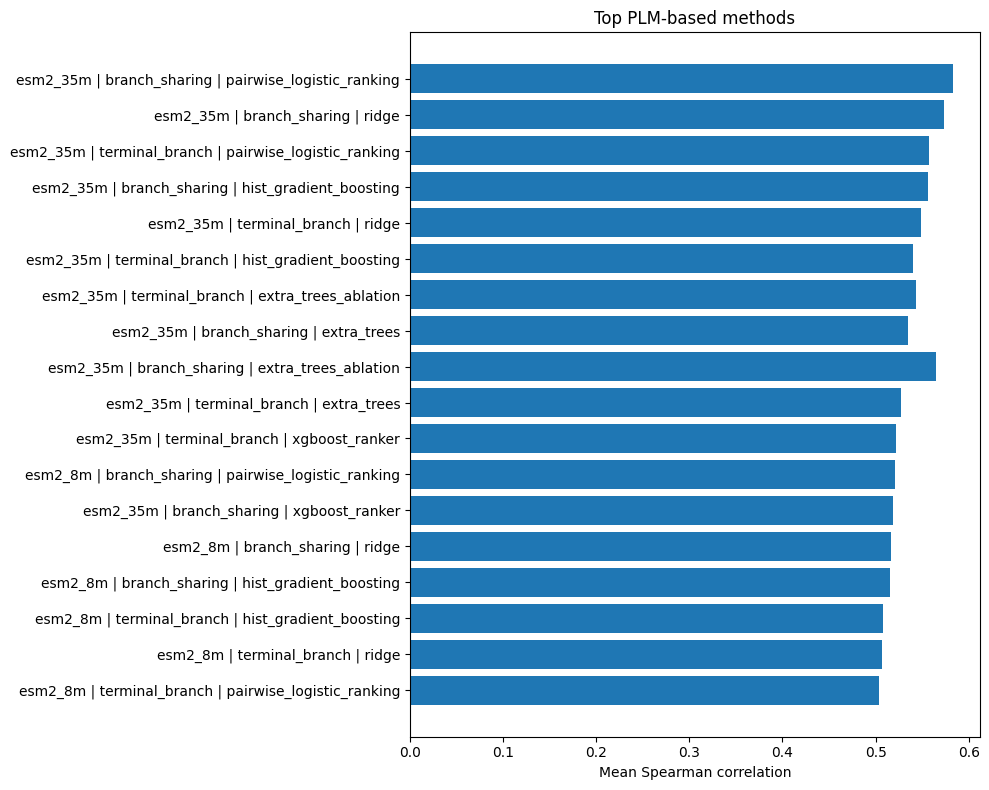

In [32]:
top_plot_df = final_summary_df.head(20).copy()
top_plot_df["label"] = (
    top_plot_df["model_key"].astype(str)
    + " | "
    + top_plot_df["phylo_method"].astype(str)
    + " | "
    + top_plot_df["method_name"].astype(str)
)

plt.figure(figsize=(10, 8))
plt.barh(top_plot_df["label"][::-1], top_plot_df["mean_spearman"][::-1])
plt.xlabel("Mean Spearman correlation")
plt.title("Top PLM-based methods")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_methods_mean_spearman.png", dpi=300)
plt.show()

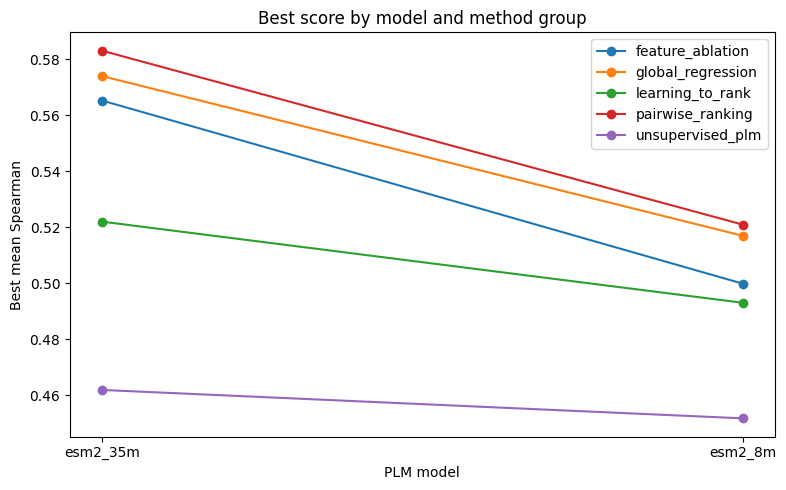

In [33]:
model_plot_df = (
    final_summary_df
    .groupby(["model_key", "method_group"])
    ["mean_spearman"]
    .max()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for method_group, part in model_plot_df.groupby("method_group"):
    plt.plot(part["model_key"], part["mean_spearman"], marker="o", label=method_group)

plt.xlabel("PLM model")
plt.ylabel("Best mean Spearman")
plt.title("Best score by model and method group")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", dpi=300)
plt.show()

## 22.1 Size-effect plots

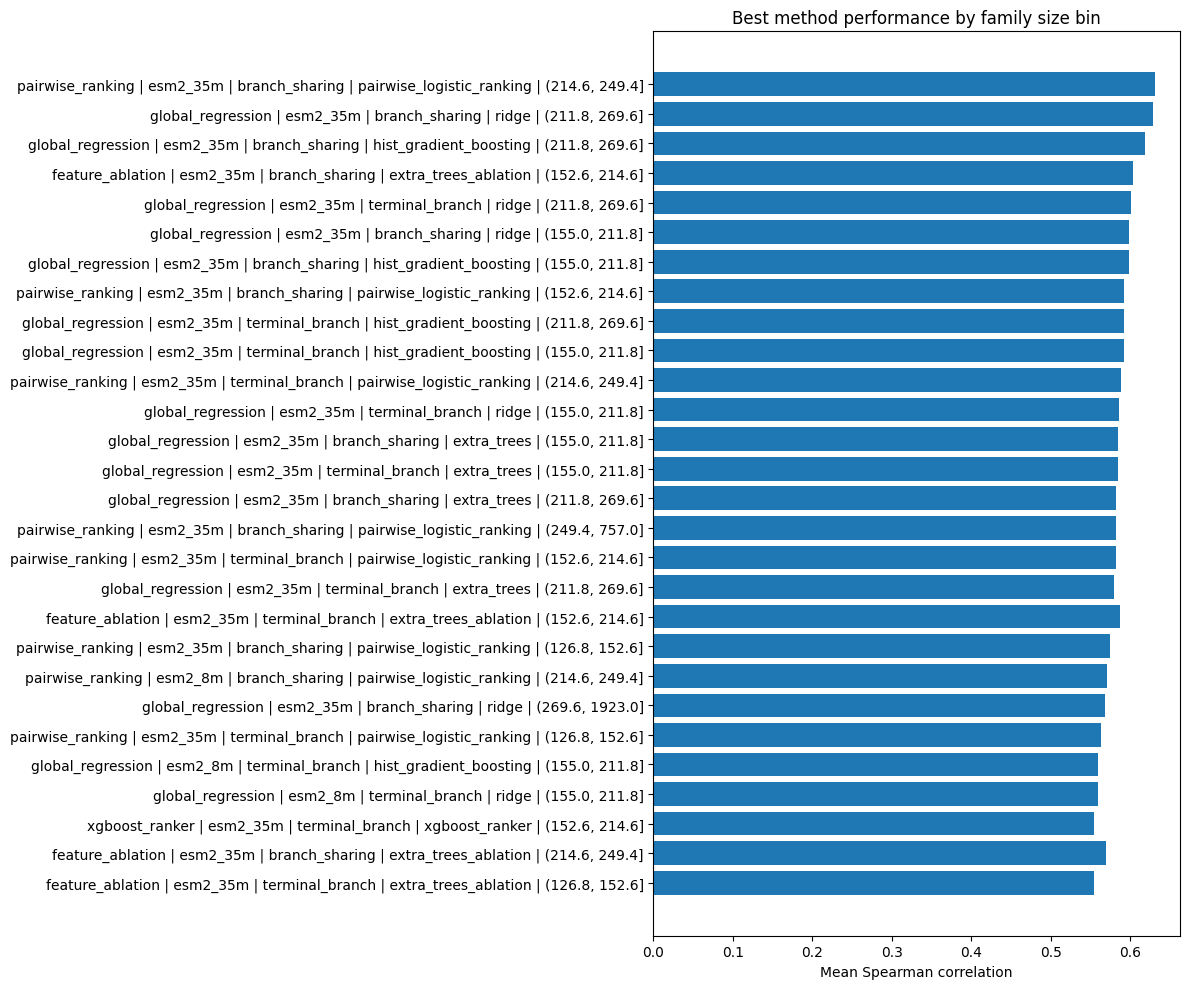

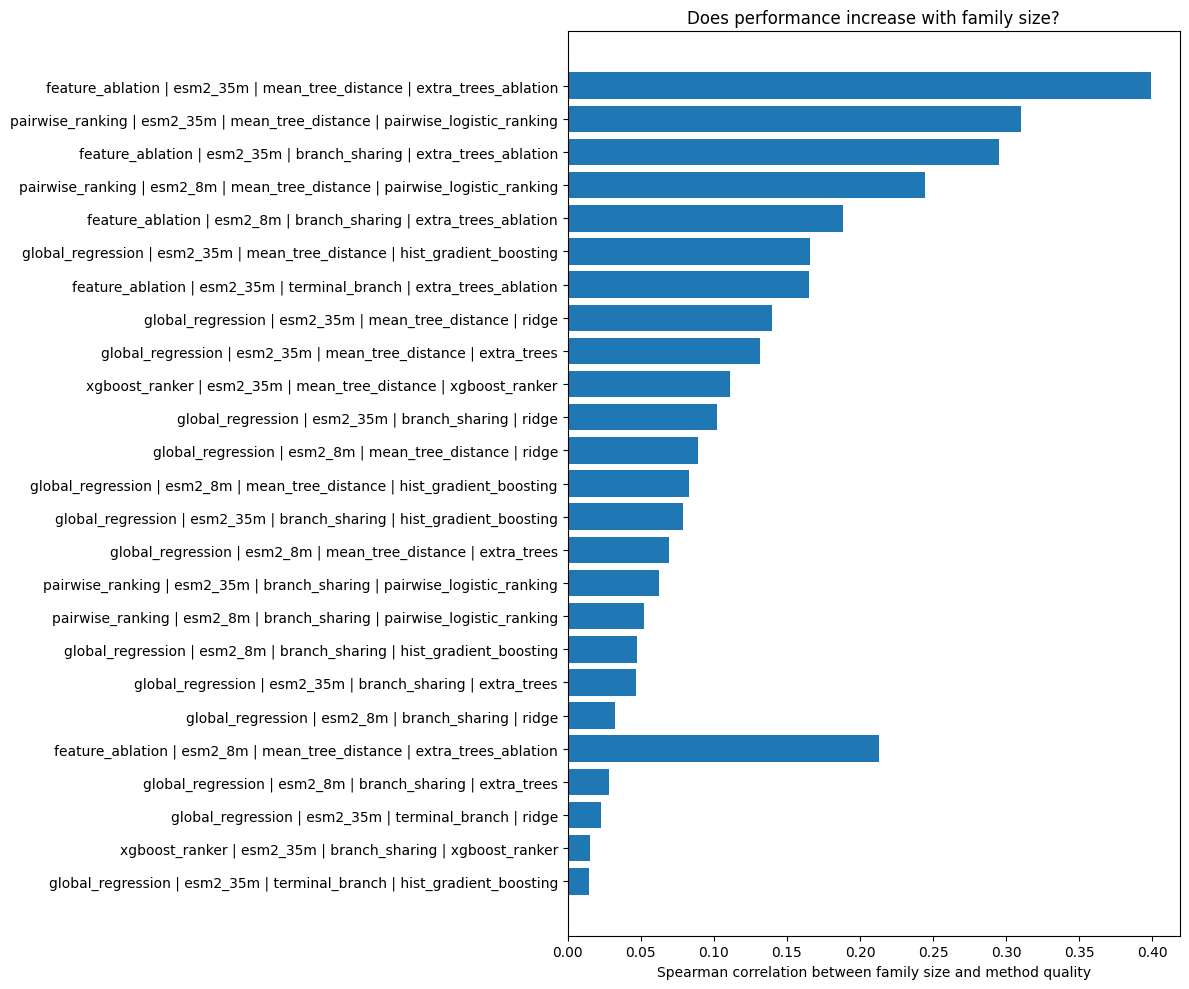

In [34]:
if "size_analysis_df" in globals() and len(size_analysis_df) > 0:
    best_size_df = (
        size_analysis_df
        .sort_values("mean_spearman", ascending=False)
        .head(30)
        .copy()
    )

    best_size_df["label"] = (
        best_size_df["source"].astype(str)
        + " | "
        + best_size_df["model_key"].astype(str)
        + " | "
        + best_size_df["phylo_method"].astype(str)
        + " | "
        + best_size_df["method_name"].astype(str)
        + " | "
        + best_size_df["size_bin"].astype(str)
    )

    plt.figure(figsize=(12, 10))
    plt.barh(best_size_df["label"][::-1], best_size_df["mean_spearman"][::-1])
    plt.xlabel("Mean Spearman correlation")
    plt.title("Best method performance by family size bin")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "size_bins_top_methods.png", dpi=300)
    plt.show()


if "size_corr_df" in globals() and len(size_corr_df) > 0:
    plot_corr_df = (
        size_corr_df
        .dropna(subset=["size_spearman_corr"])
        .sort_values("size_spearman_corr", ascending=False)
        .head(30)
        .copy()
    )

    plot_corr_df["label"] = (
        plot_corr_df["source"].astype(str)
        + " | "
        + plot_corr_df["model_key"].astype(str)
        + " | "
        + plot_corr_df["phylo_method"].astype(str)
        + " | "
        + plot_corr_df["method_name"].astype(str)
    )

    plt.figure(figsize=(12, 10))
    plt.barh(plot_corr_df["label"][::-1], plot_corr_df["size_spearman_corr"][::-1])
    plt.xlabel("Spearman correlation between family size and method quality")
    plt.title("Does performance increase with family size?")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "size_effect_correlations.png", dpi=300)
    plt.show()

## 22.2 Local feature signal plots

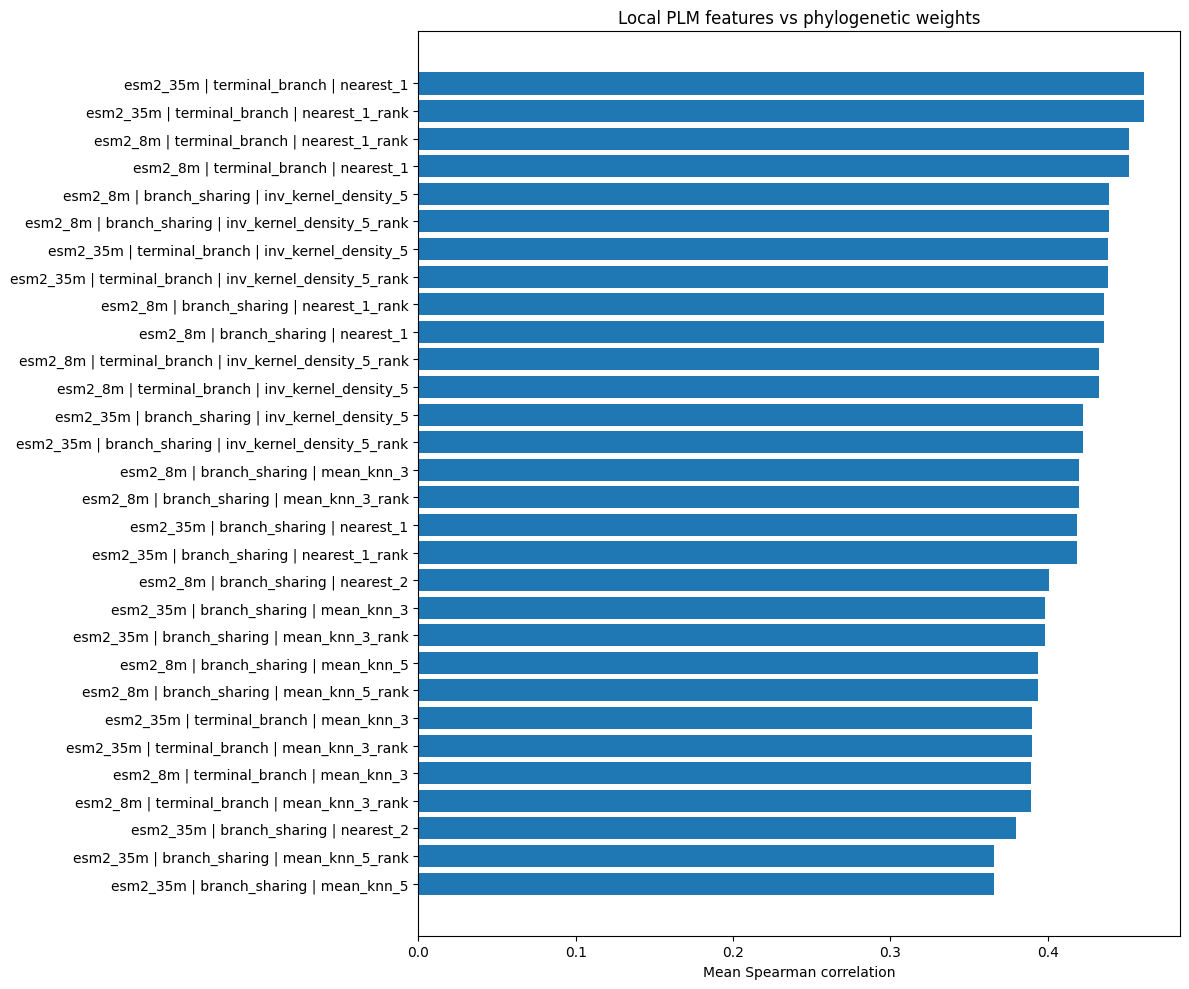

In [35]:
if "density_weight_summary_df" in globals() and len(density_weight_summary_df) > 0:
    plot_df = density_weight_summary_df.head(30).copy()
    plot_df["label"] = (
        plot_df["model_key"].astype(str)
        + " | "
        + plot_df["phylo_method"].astype(str)
        + " | "
        + plot_df["feature"].astype(str)
    )

    plt.figure(figsize=(12, 10))
    plt.barh(plot_df["label"][::-1], plot_df["mean_spearman"][::-1])
    plt.xlabel("Mean Spearman correlation")
    plt.title("Local PLM features vs phylogenetic weights")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "local_features_vs_phylo_weights.png", dpi=300)
    plt.show()

## 22.3 Графики для отчёта после полного запуска

Этот блок не пересчитывает эксперименты. Он использует уже полученные таблицы `regression_eval_df`, `ranking_eval_df`, `xgboost_eval_df`, `ablation_eval_df`, `density_weight_summary_df`, `final_summary_df` и сохраняет дополнительные рисунки в `FIG_DIR / "report_figures"`.


In [36]:

REPORT_FIG_DIR = FIG_DIR / "report_figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)


def get_filtered_eval(df, model_key=None, phylo_method=None, method_name=None, feature_group=None):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    result = df.copy()

    if model_key is not None and "model_key" in result.columns:
        result = result[result["model_key"] == model_key]

    if phylo_method is not None and "phylo_method" in result.columns:
        result = result[result["phylo_method"] == phylo_method]

    if method_name is not None and "method_name" in result.columns:
        result = result[result["method_name"] == method_name]

    if feature_group is not None and "feature_group" in result.columns:
        result = result[result["feature_group"] == feature_group]

    need_cols = {"ANO", "spearman_corr"}
    if not need_cols.issubset(result.columns):
        return pd.DataFrame()

    result = result.dropna(subset=["ANO", "spearman_corr"]).copy()
    result["ANO"] = pd.to_numeric(result["ANO"], errors="coerce")
    result["spearman_corr"] = pd.to_numeric(result["spearman_corr"], errors="coerce")
    result = result.dropna(subset=["ANO", "spearman_corr"])

    return result.sort_values("ANO")


def rolling_mean_by_size(df, window=15):
    if len(df) == 0:
        return df.copy()

    result = df.sort_values("ANO").copy()
    real_window = min(window, max(5, len(result) // 4))
    result["rolling_spearman"] = (
        result["spearman_corr"]
        .rolling(real_window, center=True, min_periods=max(3, real_window // 3))
        .mean()
    )
    return result


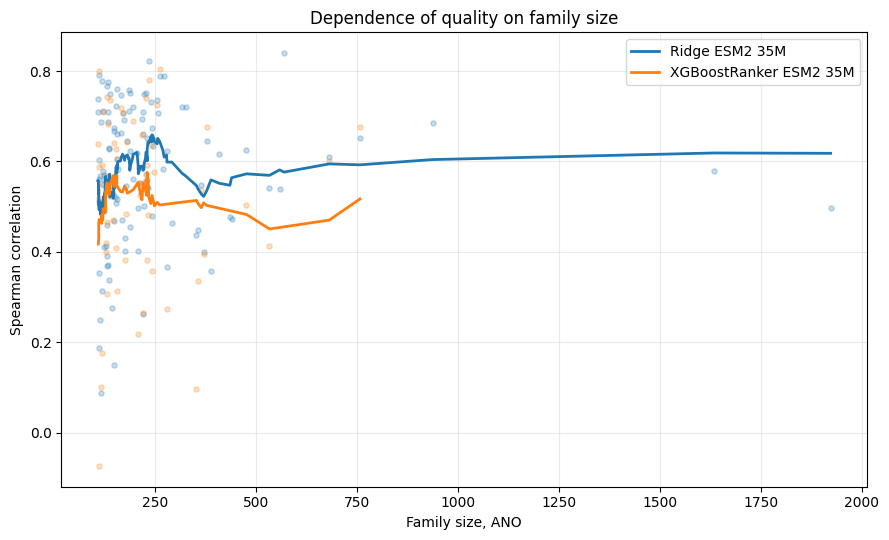

In [37]:

size_plot_parts = []

if "regression_eval_df" in globals():
    part = get_filtered_eval(
        regression_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="ridge",
    )
    if len(part) > 0:
        part["plot_method"] = "Ridge ESM2 35M"
        size_plot_parts.append(part)

if "ranking_eval_df" in globals():
    part = get_filtered_eval(
        ranking_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="pairwise_logistic",
    )
    if len(part) > 0:
        part["plot_method"] = "Pairwise ranking ESM2 35M"
        size_plot_parts.append(part)

if "xgboost_eval_df" in globals():
    part = get_filtered_eval(
        xgboost_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
    )
    if len(part) > 0:
        part["plot_method"] = "XGBoostRanker ESM2 35M"
        size_plot_parts.append(part)

if "ablation_eval_df" in globals():
    part = get_filtered_eval(
        ablation_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="extra_trees",
        feature_group="pca_plus_density",
    )
    if len(part) > 0:
        part["plot_method"] = "Extra Trees PCA + density"
        size_plot_parts.append(part)

if size_plot_parts:
    size_plot_df = pd.concat(size_plot_parts, ignore_index=True)
    size_plot_df.to_csv(REPORT_FIG_DIR / "size_dependence_per_family_points.csv", index=False)

    plt.figure(figsize=(9, 5.5))

    for method_name, part in size_plot_df.groupby("plot_method"):
        smooth = rolling_mean_by_size(part, window=15)
        plt.scatter(
            part["ANO"],
            part["spearman_corr"],
            s=14,
            alpha=0.25,
        )
        plt.plot(
            smooth["ANO"],
            smooth["rolling_spearman"],
            linewidth=2,
            label=method_name,
        )

    plt.xlabel("Family size, ANO")
    plt.ylabel("Spearman correlation")
    plt.title("Dependence of quality on family size")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(REPORT_FIG_DIR / "size_dependence_per_family.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No per-family evaluation data for size dependence plot")


<Figure size 800x500 with 0 Axes>

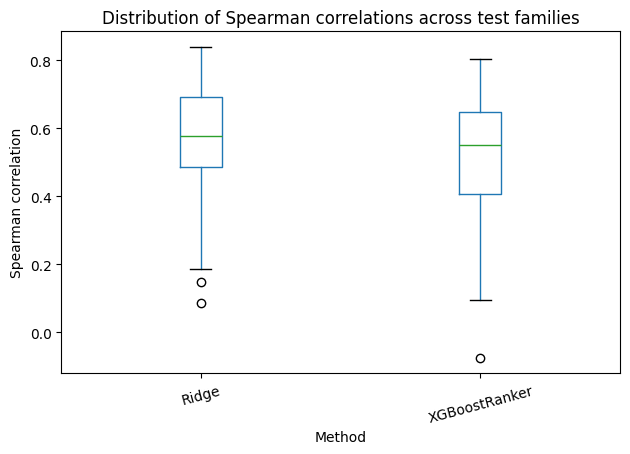

In [38]:

distribution_parts = []

if "regression_eval_df" in globals():
    part = get_filtered_eval(
        regression_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="ridge",
    )
    if len(part) > 0:
        part = part[["spearman_corr"]].copy()
        part["plot_method"] = "Ridge"
        distribution_parts.append(part)

if "ranking_eval_df" in globals():
    part = get_filtered_eval(
        ranking_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="pairwise_logistic",
    )
    if len(part) > 0:
        part = part[["spearman_corr"]].copy()
        part["plot_method"] = "Pairwise ranking"
        distribution_parts.append(part)

if "xgboost_eval_df" in globals():
    part = get_filtered_eval(
        xgboost_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
    )
    if len(part) > 0:
        part = part[["spearman_corr"]].copy()
        part["plot_method"] = "XGBoostRanker"
        distribution_parts.append(part)

if "ablation_eval_df" in globals():
    part = get_filtered_eval(
        ablation_eval_df,
        model_key="esm2_35m",
        phylo_method="branch_sharing",
        method_name="extra_trees",
        feature_group="pca_plus_density",
    )
    if len(part) > 0:
        part = part[["spearman_corr"]].copy()
        part["plot_method"] = "Extra Trees"
        distribution_parts.append(part)

if distribution_parts:
    distribution_df = pd.concat(distribution_parts, ignore_index=True)
    distribution_df.to_csv(REPORT_FIG_DIR / "method_distributions_per_family.csv", index=False)

    plt.figure(figsize=(8, 5))
    distribution_df.boxplot(
        column="spearman_corr",
        by="plot_method",
        grid=False,
        rot=15,
    )
    plt.suptitle("")
    plt.title("Distribution of Spearman correlations across test families")
    plt.xlabel("Method")
    plt.ylabel("Spearman correlation")
    plt.tight_layout()
    plt.savefig(REPORT_FIG_DIR / "method_distributions_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No per-family evaluation data for distribution plot")


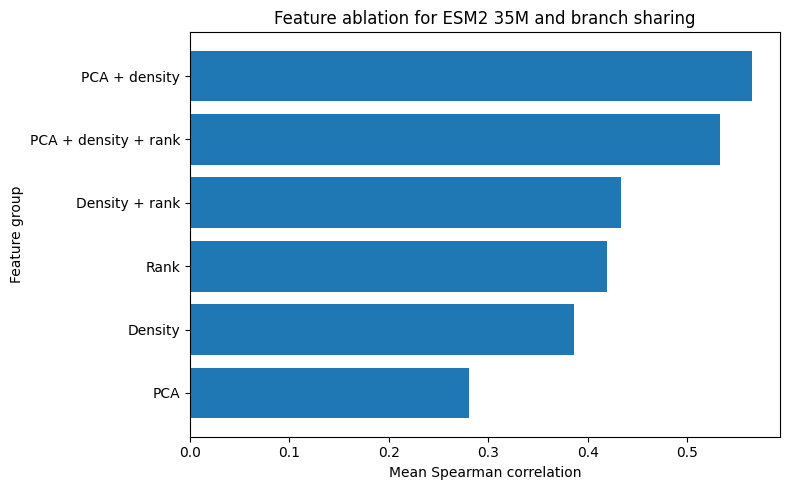

In [39]:

if "ablation_summary_df" in globals() and len(ablation_summary_df) > 0:
    plot_df = ablation_summary_df[
        (ablation_summary_df["model_key"] == "esm2_35m")
        & (ablation_summary_df["phylo_method"] == "branch_sharing")
    ].copy()

    if len(plot_df) > 0:
        plot_df = plot_df.sort_values("mean_spearman")
        plot_df.to_csv(REPORT_FIG_DIR / "feature_ablation_plot_data.csv", index=False)

        label_map = {
            "pca_only": "PCA",
            "density_only": "Density",
            "rank_only": "Rank",
            "density_plus_rank": "Density + rank",
            "pca_plus_density": "PCA + density",
            "pca_plus_density_plus_rank": "PCA + density + rank",
        }
        plot_df["plot_label"] = plot_df["feature_group"].map(label_map).fillna(plot_df["feature_group"])

        plt.figure(figsize=(8, 5))
        plt.barh(plot_df["plot_label"], plot_df["mean_spearman"])
        plt.xlabel("Mean Spearman correlation")
        plt.ylabel("Feature group")
        plt.title("Feature ablation for ESM2 35M and branch sharing")
        plt.tight_layout()
        plt.savefig(REPORT_FIG_DIR / "feature_ablation_report.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No ESM2 35M branch sharing rows in ablation_summary_df")
else:
    print("No ablation_summary_df")


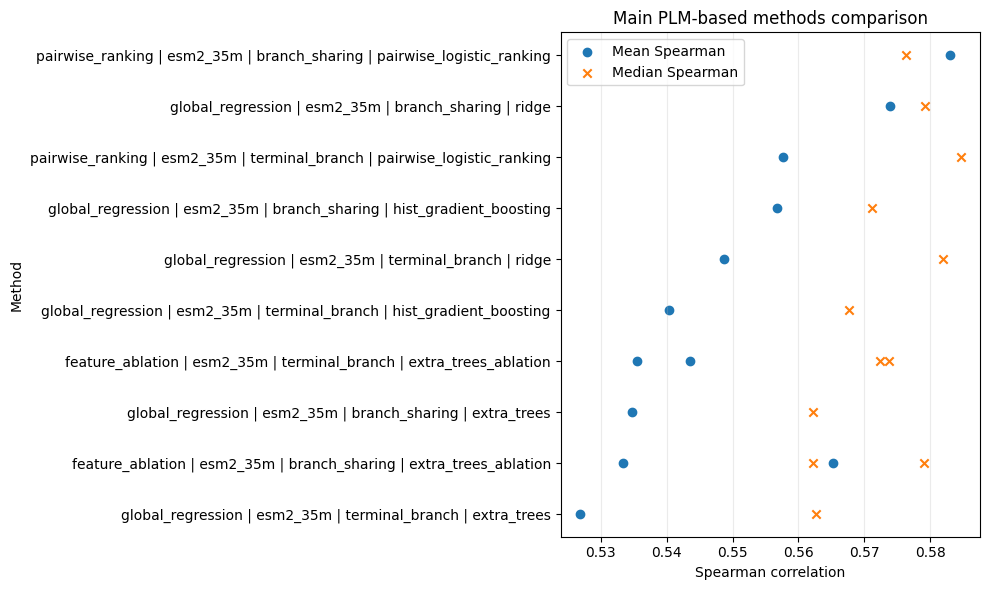

In [40]:

if "final_summary_df" in globals() and len(final_summary_df) > 0:
    plot_df = final_summary_df.copy()

    if "phylo_method" in plot_df.columns:
        plot_df = plot_df[plot_df["phylo_method"].isin(["branch_sharing", "terminal_branch", "mean_tree_distance"])]

    plot_df = plot_df.sort_values("mean_spearman", ascending=False).head(12).copy()
    plot_df["plot_label"] = (
        plot_df["method_group"].astype(str)
        + " | "
        + plot_df["model_key"].astype(str)
        + " | "
        + plot_df["phylo_method"].astype(str)
        + " | "
        + plot_df["method_name"].astype(str)
    )
    plot_df = plot_df.sort_values("mean_spearman")
    plot_df.to_csv(REPORT_FIG_DIR / "final_method_comparison_plot_data.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.scatter(plot_df["mean_spearman"], plot_df["plot_label"], label="Mean Spearman")

    if "median_spearman" in plot_df.columns:
        plt.scatter(plot_df["median_spearman"], plot_df["plot_label"], marker="x", label="Median Spearman")

    plt.xlabel("Spearman correlation")
    plt.ylabel("Method")
    plt.title("Main PLM-based methods comparison")
    plt.legend()
    plt.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(REPORT_FIG_DIR / "method_comparison_mean_median_report.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No final_summary_df")


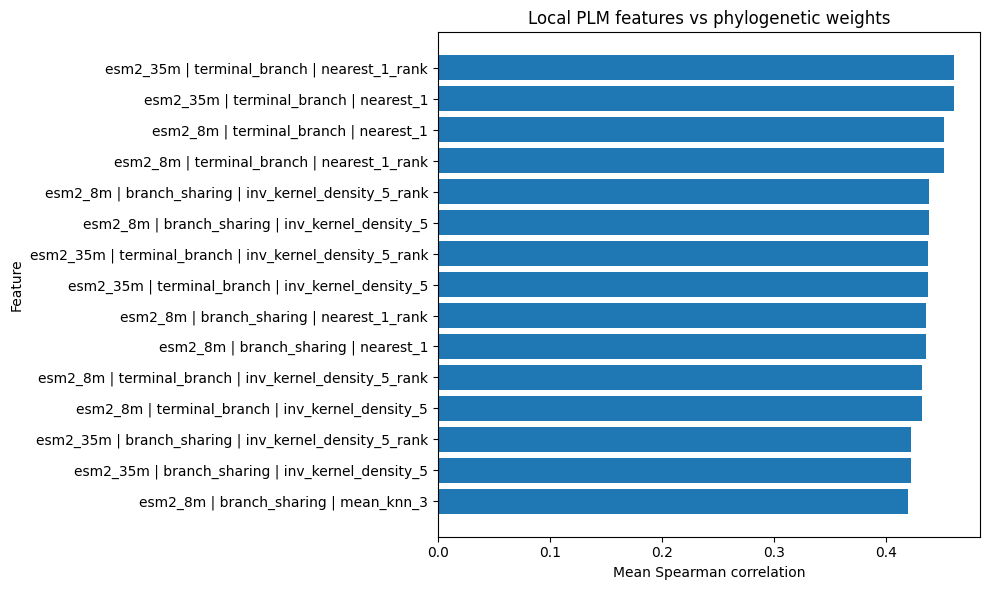

In [41]:

if "density_weight_summary_df" in globals() and len(density_weight_summary_df) > 0:
    plot_df = density_weight_summary_df.copy()

    if "model_key" in plot_df.columns:
        plot_df = plot_df[plot_df["model_key"].isin(["esm2_8m", "esm2_35m"])]

    plot_df = plot_df.sort_values("mean_spearman", ascending=False).head(15).copy()
    plot_df["plot_label"] = (
        plot_df["model_key"].astype(str)
        + " | "
        + plot_df["phylo_method"].astype(str)
        + " | "
        + plot_df["feature"].astype(str)
    )
    plot_df = plot_df.sort_values("mean_spearman")
    plot_df.to_csv(REPORT_FIG_DIR / "local_feature_signal_plot_data.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["plot_label"], plot_df["mean_spearman"])
    plt.xlabel("Mean Spearman correlation")
    plt.ylabel("Feature")
    plt.title("Local PLM features vs phylogenetic weights")
    plt.tight_layout()
    plt.savefig(REPORT_FIG_DIR / "local_feature_signal_report.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No density_weight_summary_df")


In [42]:

print("Report figures:")
for path in sorted(REPORT_FIG_DIR.glob("*.png")):
    print(path.name)

print("\nReport figure data:")
for path in sorted(REPORT_FIG_DIR.glob("*.csv")):
    print(path.name)


Report figures:
feature_ablation_report.png
local_feature_signal_report.png
method_comparison_mean_median_report.png
method_distributions_boxplot.png
size_dependence_per_family.png

Report figure data:
feature_ablation_plot_data.csv
final_method_comparison_plot_data.csv
local_feature_signal_plot_data.csv
method_distributions_per_family.csv
size_dependence_per_family_points.csv


## 23. Контроль сохранённых файлов

In [43]:
print("Results:")
for path in sorted(RESULT_DIR.glob("*.csv")):
    print(path.name)

print("\\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(path.name)

Results:
density_features_vs_phylo_weights.csv
density_features_vs_phylo_weights_by_size.csv
density_features_vs_phylo_weights_summary.csv
family_checks.csv
feature_ablation_eval.csv
feature_ablation_predictions.csv
feature_ablation_summary.csv
final_summary.csv
global_regression_eval.csv
global_regression_predictions.csv
global_regression_summary.csv
pairwise_ranking_eval.csv
pairwise_ranking_predictions.csv
phylo_target_comparison.csv
plm_unsupervised_results.csv
plm_unsupervised_summary.csv
size_analysis_summary.csv
size_correlation_summary.csv
xgboost_ranker_eval.csv
xgboost_ranker_predictions.csv
\nFigures:
local_features_vs_phylo_weights.png
model_comparison.png
size_bins_top_methods.png
size_effect_correlations.png
top_methods_mean_spearman.png
